# Unsupervised Exploration of Multi-Athlete Data

In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
DATA = '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/athletes/all_athletes_daily_master.parquet'
METADATA = 'data_processed/athletes/all_athletes_daily_master_metadata.json'

In [9]:
# Load the data into a pandas DataFrame
df = pd.read_parquet(DATA)

In [12]:
# Inspect the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28542 entries, 0 to 28541
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            28542 non-null  datetime64[ns]
 1   athlete_id                      28542 non-null  object        
 2   total_distance_km               28542 non-null  float64       
 3   total_duration_minutes          28542 non-null  float64       
 4   readiness_score_last            4289 non-null   float64       
 5   readiness_level_last            4307 non-null   object        
 6   recovery_time_last              4307 non-null   float64       
 7   acute_load_last                 4304 non-null   float64       
 8   sleep_score_last                4003 non-null   float64       
 9   valid_sleep_any                 4307 non-null   object        
 10  readiness_snapshots             4307 non-null   float64       
 11  lo

In [ ]:
coverage_features = [
    'total_distance_km',
    'total_training_load',
    'avg_hr',
    'avg_pace_mile',
    'avg_cadence',
    'aerobic_te_avg',
    'vo2max',
    'max_met',
    '5K_pred',
    'training_status',
    'readiness_score_last',
    'sleep_score_last',
    'hrv_weekly_avg_last',
    'dailyTrainingLoadAcute',
    'dailyTrainingLoadChronic',
    'avg_power'
]

# Avoid errors if a listed feature is absent
coverage_features = [
    col for col in coverage_features if col in df.columns
]

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['athlete_id', 'date']).copy()

In [19]:
# Convert from wide to long format
coverage_long = df.melt(
    id_vars=['athlete_id', 'date'],
    value_vars=coverage_features,
    var_name='feature',
    value_name='value'
)

coverage_long['available'] = coverage_long['value'].notna()

athlete_days = (
    df.groupby('athlete_id')['date']
      .nunique()
      .rename('total_days')
)

athlete_feature_coverage = (
    coverage_long
    .groupby(['athlete_id', 'feature'], observed=True)
    .agg(
        non_null_days=('available', 'sum'),
        first_available_date=(
            'date',
            lambda dates: dates[
                coverage_long.loc[dates.index, 'available']
            ].min()
        ),
        last_available_date=(
            'date',
            lambda dates: dates[
                coverage_long.loc[dates.index, 'available']
            ].max()
        )
    )
    .reset_index()
    .merge(athlete_days, on='athlete_id', how='left')
)

athlete_feature_coverage['coverage_pct'] = (
    100
    * athlete_feature_coverage['non_null_days']
    / athlete_feature_coverage['total_days']
)

athlete_feature_coverage

,athlete_id,feature,non_null_days,first_available_date,last_available_date,total_days,coverage_pct
0,athlete_001,5K_pred,693,2024-06-19,2026-05-12,3468,19.982699
1,athlete_001,aerobic_te_avg,667,2021-07-08,2026-05-07,3468,19.232987
2,athlete_001,avg_cadence,667,2021-07-08,2026-05-07,3468,19.232987
3,athlete_001,avg_hr,667,2021-07-08,2026-05-07,3468,19.232987
4,athlete_001,avg_pace_mile,682,2016-11-13,2026-05-07,3468,19.665513
...,...,...,...,...,...,...,...
123,athlete_008,sleep_score_last,1068,2023-08-15,2026-07-31,3702,28.849271
124,athlete_008,total_distance_km,3702,2016-06-12,2026-07-31,3702,100.000000
125,athlete_008,total_training_load,3702,2016-06-12,2026-07-31,3702,100.000000
126,athlete_008,training_status,1803,2021-08-24,2026-07-31,3702,48.703404


In [20]:
def count_availability_periods(group, max_gap_days=7):
    available_dates = (
        group.loc[group['available'], 'date']
        .drop_duplicates()
        .sort_values()
    )

    if available_dates.empty:
        return 0

    gaps = available_dates.diff().dt.days
    return 1 + (gaps > max_gap_days).sum()

In [21]:
availability_periods = (
    coverage_long
    .groupby(['athlete_id', 'feature'], observed=True)
    .apply(
        count_availability_periods,
        max_gap_days=7,
        include_groups=False
    )
    .rename('distinct_periods')
    .reset_index()
)

athlete_feature_coverage = athlete_feature_coverage.merge(
    availability_periods,
    on=['athlete_id', 'feature'],
    how='left'
)

athlete_feature_coverage['distinct_periods'] = (
    athlete_feature_coverage['distinct_periods']
    .fillna(0)
    .astype(int)
)

In [23]:
athlete_feature_coverage = (
    athlete_feature_coverage[
        [
            'athlete_id',
            'feature',
            'non_null_days',
            'total_days',
            'coverage_pct',
            'first_available_date',
            'last_available_date',
            'distinct_periods'
        ]
    ]
    .sort_values(['athlete_id', 'feature'])
    .reset_index(drop=True)
)

athlete_feature_coverage

,athlete_id,feature,non_null_days,total_days,coverage_pct,first_available_date,last_available_date,distinct_periods
0,athlete_001,5K_pred,693,3468,19.982699,2024-06-19,2026-05-12,1
1,athlete_001,aerobic_te_avg,667,3468,19.232987,2021-07-08,2026-05-07,28
2,athlete_001,avg_cadence,667,3468,19.232987,2021-07-08,2026-05-07,28
3,athlete_001,avg_hr,667,3468,19.232987,2021-07-08,2026-05-07,28
4,athlete_001,avg_pace_mile,682,3468,19.665513,2016-11-13,2026-05-07,37
...,...,...,...,...,...,...,...,...
123,athlete_008,sleep_score_last,1068,3702,28.849271,2023-08-15,2026-07-31,2
124,athlete_008,total_distance_km,3702,3702,100.000000,2016-06-12,2026-07-31,1
125,athlete_008,total_training_load,3702,3702,100.000000,2016-06-12,2026-07-31,1
126,athlete_008,training_status,1803,3702,48.703404,2021-08-24,2026-07-31,1


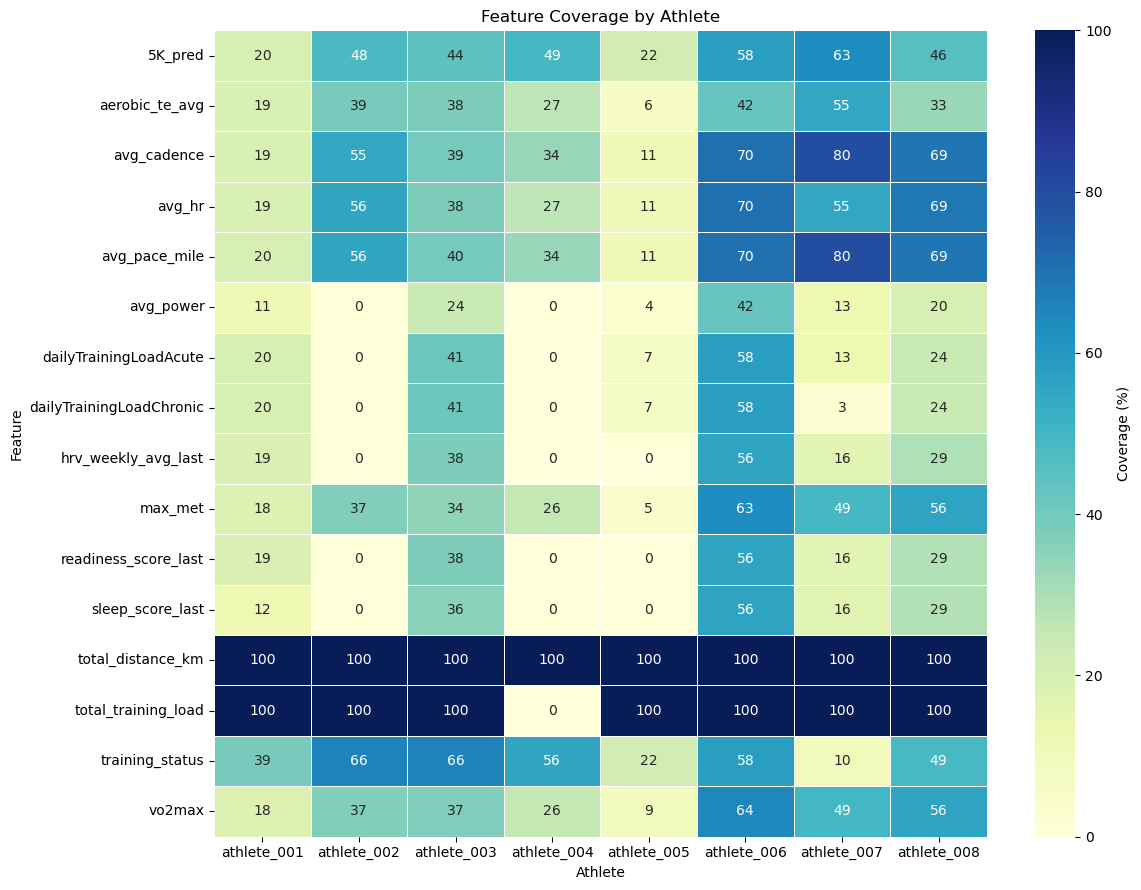

In [26]:
coverage_matrix = athlete_feature_coverage.pivot(
    index='feature',
    columns='athlete_id',
    values='coverage_pct'
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    coverage_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Coverage (%)'}
)

plt.title('Feature Coverage by Athlete')
plt.xlabel('Athlete')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [27]:
feature_families = {
    'basic_activity': [
        'total_distance_km',
        'total_duration_minutes',
        'run_count',
        'total_elevation_gain_m'
    ],
    'run_dynamics': [
        'avg_hr',
        'avg_pace_mile',
        'avg_cadence',
        'avg_stride_length_m'
    ],
    'training_stimulus': [
        'total_training_load',
        'aerobic_te_avg',
        'anaerobic_te_avg'
    ],
    'training_status': [
        'acute_load_last',
        'load_tunnel_min',
        'load_tunnel_max',
        'training_status'
    ],
    'recovery': [
        'readiness_score_last',
        'recovery_time_last',
        'sleep_score_last',
        'hrv_weekly_avg_last'
    ],
    'workload_balance': [
        'dailyTrainingLoadAcute',
        'dailyTrainingLoadChronic',
        'dailyAcuteChronicWorkloadRatio'
    ],
    'fitness_estimates': [
        'vo2max',
        'max_met',
        '5K_pred',
        '10K_pred',
        'Half_pred',
        'Marathon_pred'
    ],
    'power': [
        'avg_power',
        'max_power'
    ]
}

# Retain only columns that actually exist
feature_families = {
    family: [col for col in columns if col in df.columns]
    for family, columns in feature_families.items()
}

In [28]:
df['basic_activity_available'] = (
    df['total_distance_km'].notna()
    & df['total_duration_minutes'].notna()
)

df['training_session_available'] = (
    df['total_distance_km'].notna()
    & df['total_duration_minutes'].notna()
    & df[
        [
            'avg_hr',
            'total_training_load',
            'avg_pace_mile'
        ]
    ].notna().any(axis=1)
)

df['recovery_available'] = (
    df[
        [
            'readiness_score_last',
            'sleep_score_last',
            'hrv_weekly_avg_last'
        ]
    ].notna().all(axis=1)
)

df['fitness_available'] = (
    df[['vo2max', 'max_met']].notna().any(axis=1)
    & df[
        ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']
    ].notna().any(axis=1)
)

df['power_available'] = (
    df[['avg_power', 'max_power']].notna().any(axis=1)
)

In [29]:
family_flags = [
    'basic_activity_available',
    'training_session_available',
    'recovery_available',
    'fitness_available',
    'power_available'
]

athlete_family_coverage = (
    df.groupby('athlete_id')[family_flags]
      .mean()
      .mul(100)
)

athlete_family_coverage

,basic_activity_available,training_session_available,recovery_available,fitness_available,power_available
athlete_id,,,,,
athlete_001,100.0,100.000000,12.370242,11.274510,10.957324
athlete_002,100.0,100.000000,0.000000,25.742319,0.000000
athlete_003,100.0,100.000000,35.668140,23.937436,24.345461
athlete_004,100.0,33.525062,0.000000,23.555190,0.000000
athlete_005,100.0,100.000000,0.000000,4.587459,3.679868
athlete_006,100.0,100.000000,56.024096,38.554217,42.289157
athlete_007,100.0,100.000000,16.316285,47.976153,12.676498
athlete_008,100.0,100.000000,28.687196,30.686116,19.584009


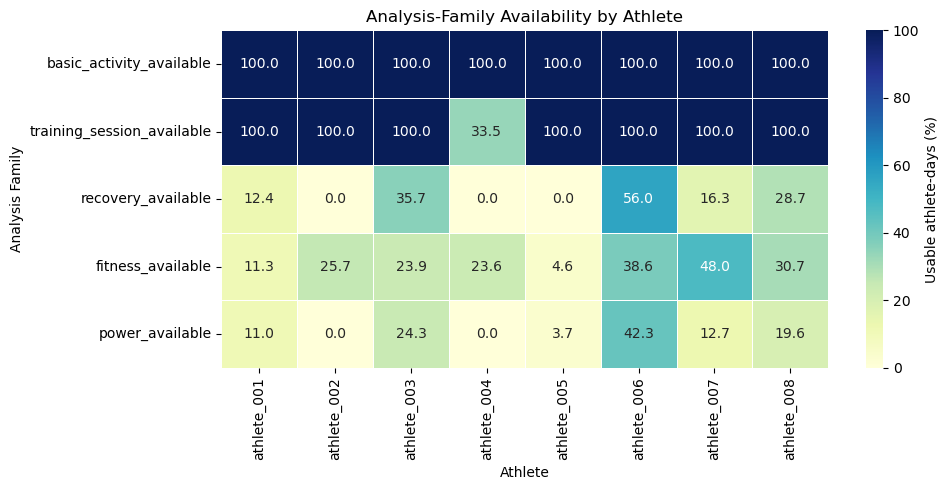

In [30]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    athlete_family_coverage.T,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Usable athlete-days (%)'}
)

plt.title('Analysis-Family Availability by Athlete')
plt.xlabel('Athlete')
plt.ylabel('Analysis Family')
plt.tight_layout()
plt.show()

In [31]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["athlete_id", "date"])

# A running day is any day with positive run count or distance.
df["is_running_day"] = (
    df["run_count"].fillna(0).gt(0)
    | df["total_distance_km"].fillna(0).gt(0)
)

In [32]:
running_features = [
    "avg_hr",
    "avg_pace_mile",
    "avg_cadence",
    "avg_stride_length_m",
    "total_training_load",
    "aerobic_te_avg",
    "anaerobic_te_avg",
    "avg_power",
]

fitness_features = [
    "vo2max",
    "max_met",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred",
]

recovery_features = [
    "readiness_score_last",
    "sleep_score_last",
    "hrv_weekly_avg_last",
]

# Keep only columns present in the dataframe.
running_features = [c for c in running_features if c in df.columns]
fitness_features = [c for c in fitness_features if c in df.columns]
recovery_features = [c for c in recovery_features if c in df.columns]

In [33]:
# A session is usable when it has distance and duration plus at least
# two descriptive running metrics.
df["running_session_usable"] = (
    df["is_running_day"]
    & df["total_distance_km"].notna()
    & df["total_duration_minutes"].notna()
    & df[running_features].notna().sum(axis=1).ge(2)
)

# Fitness analysis: at least one fitness estimate and one race prediction.
fitness_level_features = [
    c for c in ["vo2max", "max_met"] if c in df.columns
]

race_prediction_features = [
    c for c in ["5K_pred", "10K_pred", "Half_pred", "Marathon_pred"]
    if c in df.columns
]

df["fitness_usable"] = (
    df[fitness_level_features].notna().any(axis=1)
    & df[race_prediction_features].notna().any(axis=1)
)

# Strict recovery cohort.
df["recovery_usable_strict"] = (
    df[recovery_features].notna().all(axis=1)
)

# Relaxed version, useful for checking how many extra days become available.
df["recovery_usable_relaxed"] = (
    df[recovery_features].notna().sum(axis=1).ge(2)
)

In [34]:
def pct(numerator, denominator):
    if denominator == 0:
        return np.nan
    return 100 * numerator / denominator

In [35]:
summary_rows = []

for athlete_id, athlete_df in df.groupby("athlete_id"):
    running_df = athlete_df[athlete_df["is_running_day"]]

    row = {
        "athlete_id": athlete_id,
        "first_date": athlete_df["date"].min(),
        "last_date": athlete_df["date"].max(),
        "calendar_days": athlete_df["date"].nunique(),
        "running_days": running_df["date"].nunique(),
        "usable_running_sessions": running_df[
            "running_session_usable"
        ].sum(),
        "fitness_era_days": athlete_df["fitness_usable"].sum(),
        "recovery_era_days_strict": athlete_df[
            "recovery_usable_strict"
        ].sum(),
        "recovery_era_days_relaxed": athlete_df[
            "recovery_usable_relaxed"
        ].sum(),
    }

    # Coverage is calculated only among running days.
    for feature in running_features:
        row[f"{feature}_running_pct"] = pct(
            running_df[feature].notna().sum(),
            len(running_df),
        )

    summary_rows.append(row)

athlete_cohort_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("athlete_id")
    .reset_index(drop=True)
)

athlete_cohort_summary

,athlete_id,first_date,last_date,calendar_days,running_days,usable_running_sessions,fitness_era_days,recovery_era_days_strict,recovery_era_days_relaxed,avg_hr_running_pct,avg_pace_mile_running_pct,avg_cadence_running_pct,avg_stride_length_m_running_pct,total_training_load_running_pct,aerobic_te_avg_running_pct,anaerobic_te_avg_running_pct,avg_power_running_pct
0,athlete_001,2016-11-13,2026-05-12,3468,682,682,391,429,657,97.800587,100.000000,97.800587,97.360704,100.0,97.800587,97.800587,55.718475
1,athlete_002,2015-11-22,2026-06-29,3873,2158,2158,997,0,0,99.860982,99.907322,99.073216,99.258573,100.0,69.462465,69.416126,0.000000
2,athlete_003,2018-06-11,2026-06-29,2941,1167,1167,704,1049,1110,94.601542,100.000000,99.485861,99.485861,100.0,94.944302,86.632391,61.353899
3,athlete_004,2016-07-17,2026-07-15,3651,1225,1224,860,0,0,79.428571,99.918367,100.000000,99.918367,0.0,80.326531,80.326531,0.000000
4,athlete_005,2009-12-13,2026-07-16,6060,645,645,278,0,0,99.069767,99.844961,99.534884,99.069767,100.0,55.503876,55.503876,34.573643
5,athlete_006,2021-12-31,2026-07-17,1660,1170,1170,640,930,932,100.000000,100.000000,100.000000,100.000000,100.0,60.000000,60.000000,60.000000
6,athlete_007,2017-10-24,2026-07-15,3187,2546,2546,1529,520,521,69.010212,100.000000,100.000000,99.960723,100.0,69.010212,68.460330,15.868028
7,athlete_008,2016-06-12,2026-07-31,3702,2548,2548,1136,1062,1072,99.882261,100.000000,100.000000,99.764521,100.0,48.076923,48.037677,28.453689


In [36]:
important_summary = athlete_cohort_summary[
    [
        "athlete_id",
        "calendar_days",
        "running_days",
        "usable_running_sessions",
        "avg_hr_running_pct",
        "avg_pace_mile_running_pct",
        "total_training_load_running_pct",
        "aerobic_te_avg_running_pct",
        "fitness_era_days",
        "recovery_era_days_strict",
        "recovery_era_days_relaxed",
        "avg_power_running_pct",
    ]
]

important_summary.round(1)

,athlete_id,calendar_days,running_days,usable_running_sessions,avg_hr_running_pct,avg_pace_mile_running_pct,total_training_load_running_pct,aerobic_te_avg_running_pct,fitness_era_days,recovery_era_days_strict,recovery_era_days_relaxed,avg_power_running_pct
0,athlete_001,3468,682,682,97.8,100.0,100.0,97.8,391,429,657,55.7
1,athlete_002,3873,2158,2158,99.9,99.9,100.0,69.5,997,0,0,0.0
2,athlete_003,2941,1167,1167,94.6,100.0,100.0,94.9,704,1049,1110,61.4
3,athlete_004,3651,1225,1224,79.4,99.9,0.0,80.3,860,0,0,0.0
4,athlete_005,6060,645,645,99.1,99.8,100.0,55.5,278,0,0,34.6
5,athlete_006,1660,1170,1170,100.0,100.0,100.0,60.0,640,930,932,60.0
6,athlete_007,3187,2546,2546,69.0,100.0,100.0,69.0,1529,520,521,15.9
7,athlete_008,3702,2548,2548,99.9,100.0,100.0,48.1,1136,1062,1072,28.5


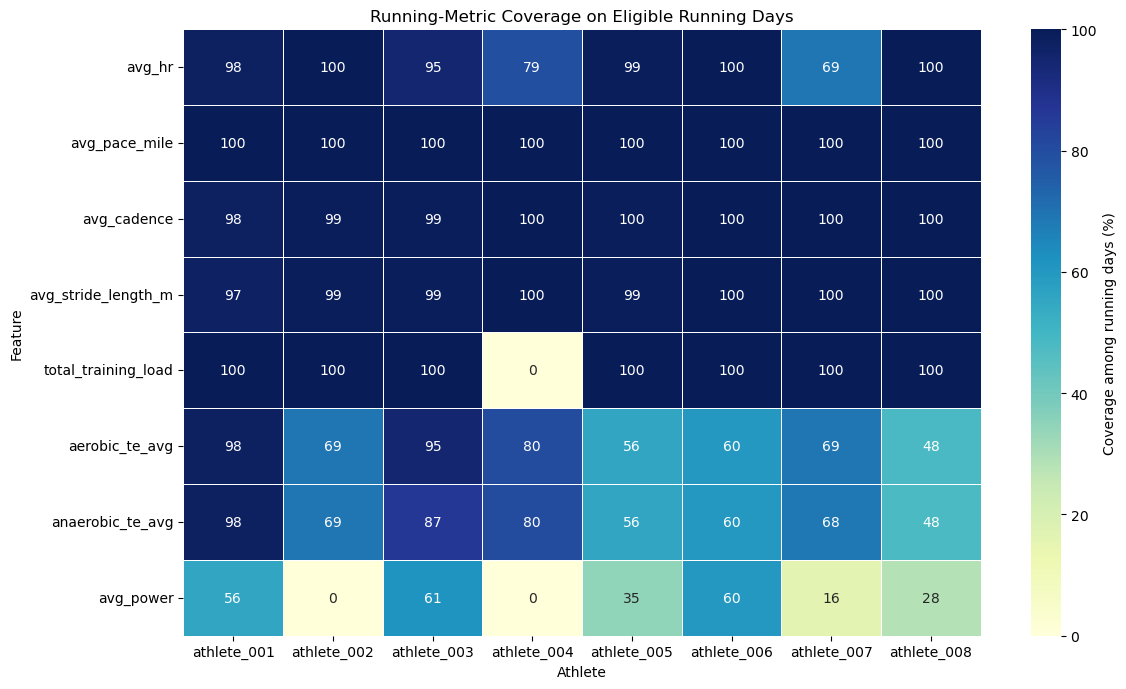

In [37]:
running_coverage_columns = [
    f"{feature}_running_pct"
    for feature in running_features
]

running_coverage_matrix = (
    athlete_cohort_summary
    .set_index("athlete_id")[running_coverage_columns]
    .rename(
        columns={
            f"{feature}_running_pct": feature
            for feature in running_features
        }
    )
    .T
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    running_coverage_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Coverage among running days (%)"},
)

plt.title("Running-Metric Coverage on Eligible Running Days")
plt.xlabel("Athlete")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [38]:
timeline_features = [
    "avg_hr",
    "avg_pace_mile",
    "total_training_load",
    "aerobic_te_avg",
    "vo2max",
    "5K_pred",
    "readiness_score_last",
    "sleep_score_last",
    "hrv_weekly_avg_last",
    "avg_power",
]

timeline_features = [
    c for c in timeline_features if c in df.columns
]

In [39]:
def plot_athlete_timeline(data, athlete_id, features):
    athlete_df = (
        data.loc[
            data["athlete_id"].eq(athlete_id),
            ["date"] + features,
        ]
        .set_index("date")
        .sort_index()
    )

    monthly_availability = (
        athlete_df[features]
        .notna()
        .resample("MS")
        .mean()
        .T
    )

    plt.figure(figsize=(16, 6))

    sns.heatmap(
        monthly_availability,
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Proportion of calendar days available"},
    )

    plt.title(f"Monthly Feature Availability: {athlete_id}")
    plt.xlabel("Month")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

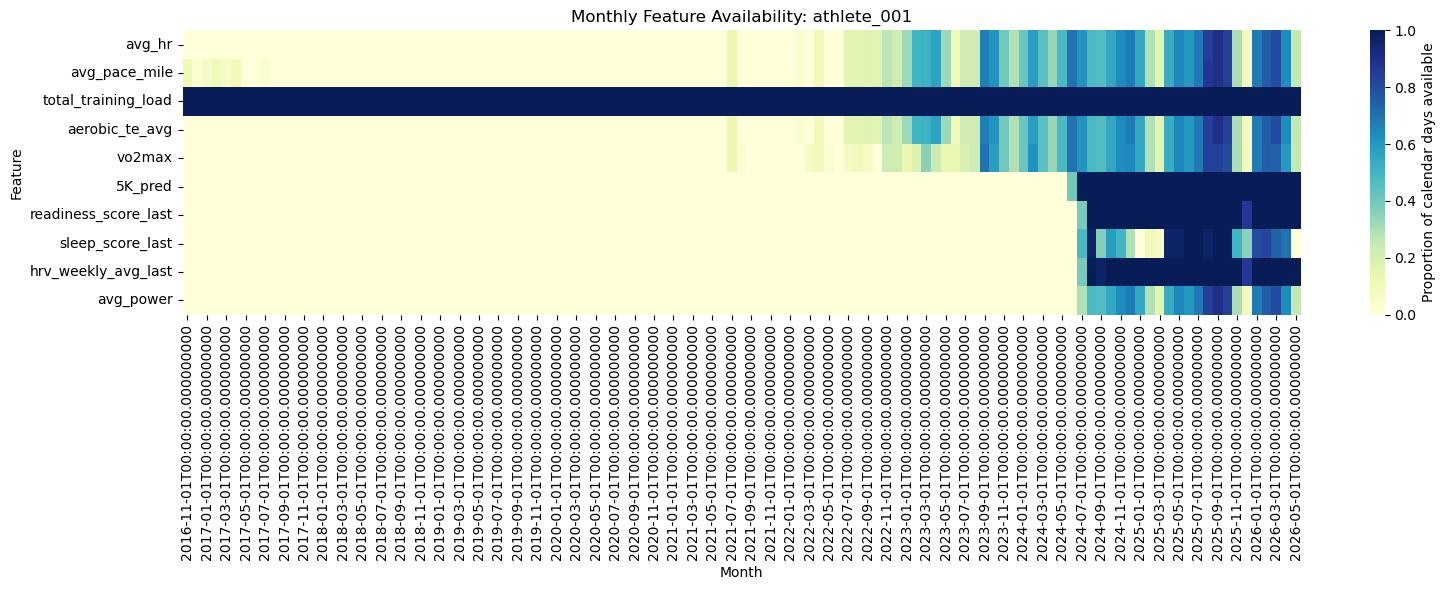

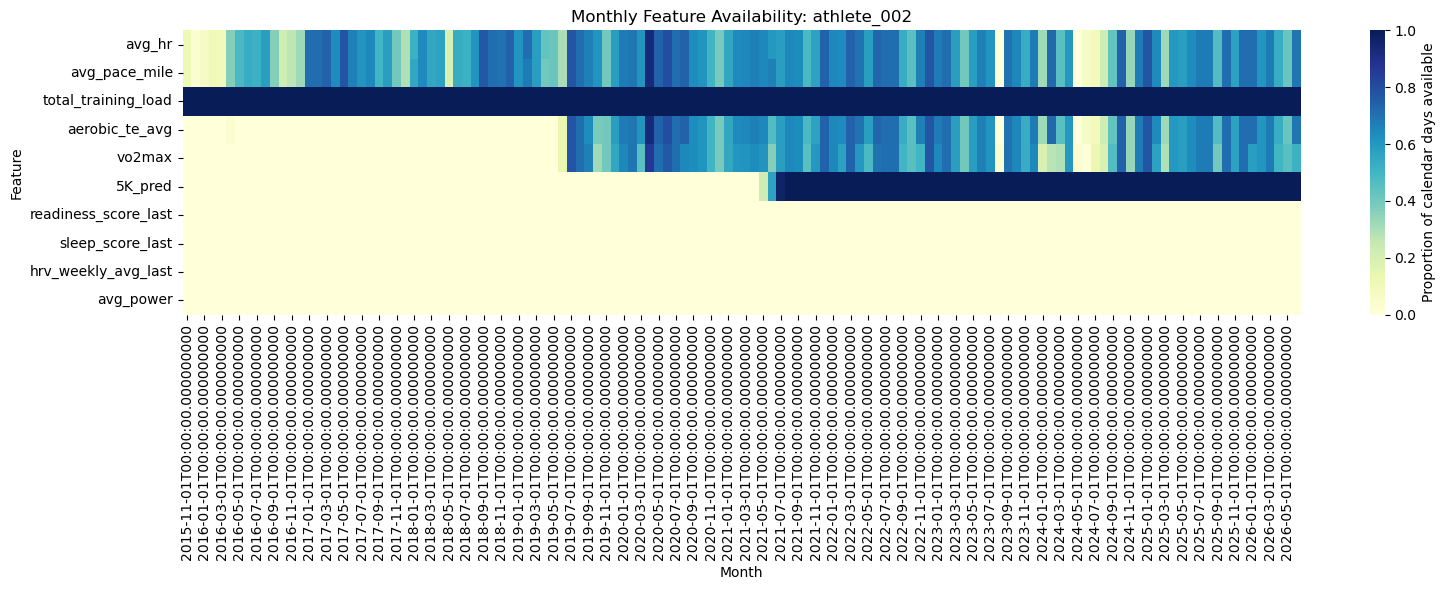

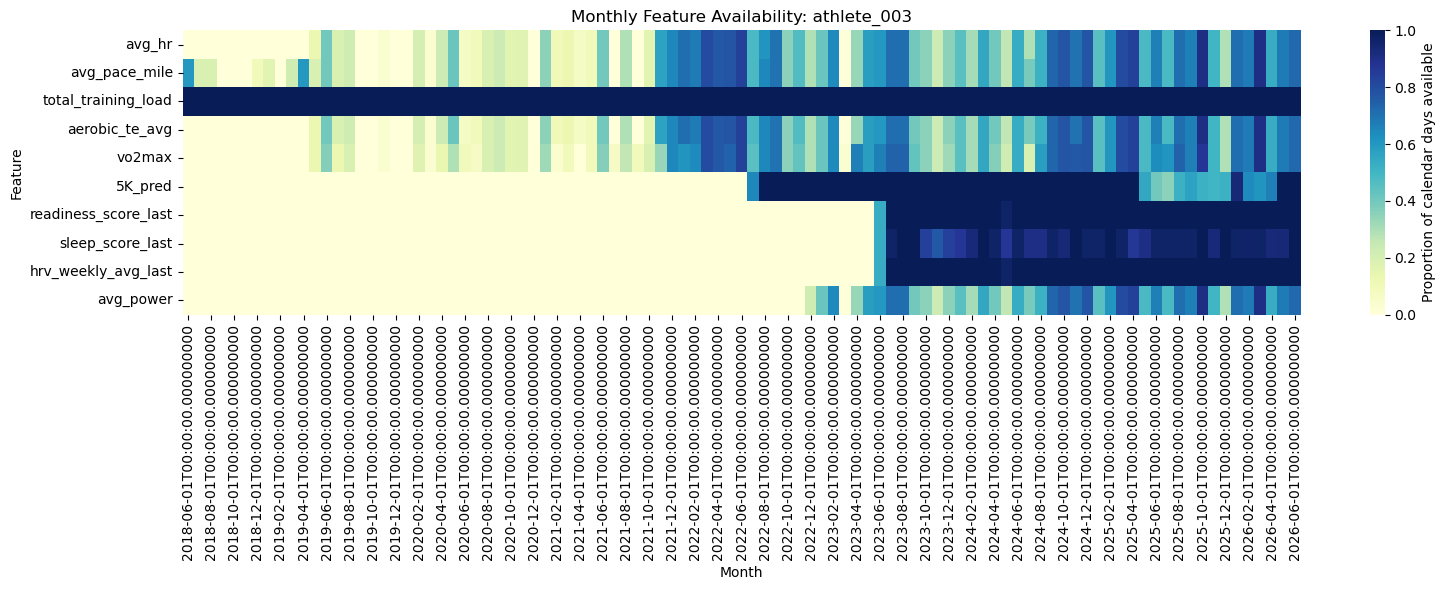

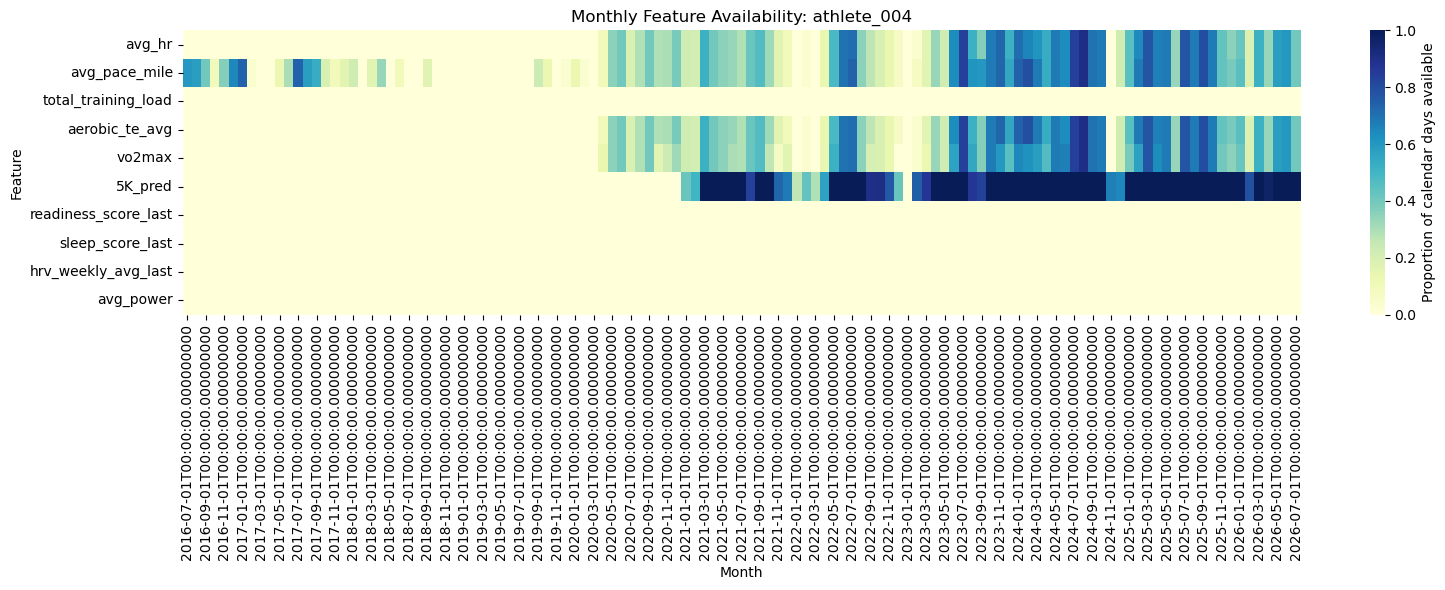

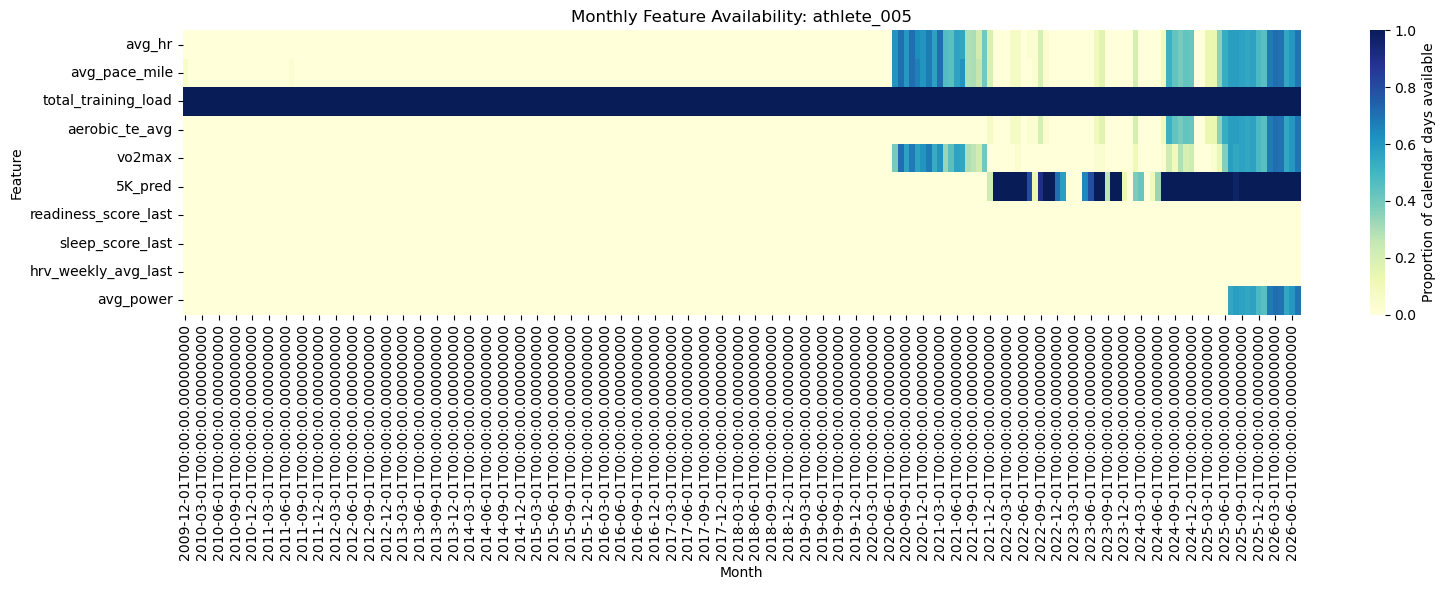

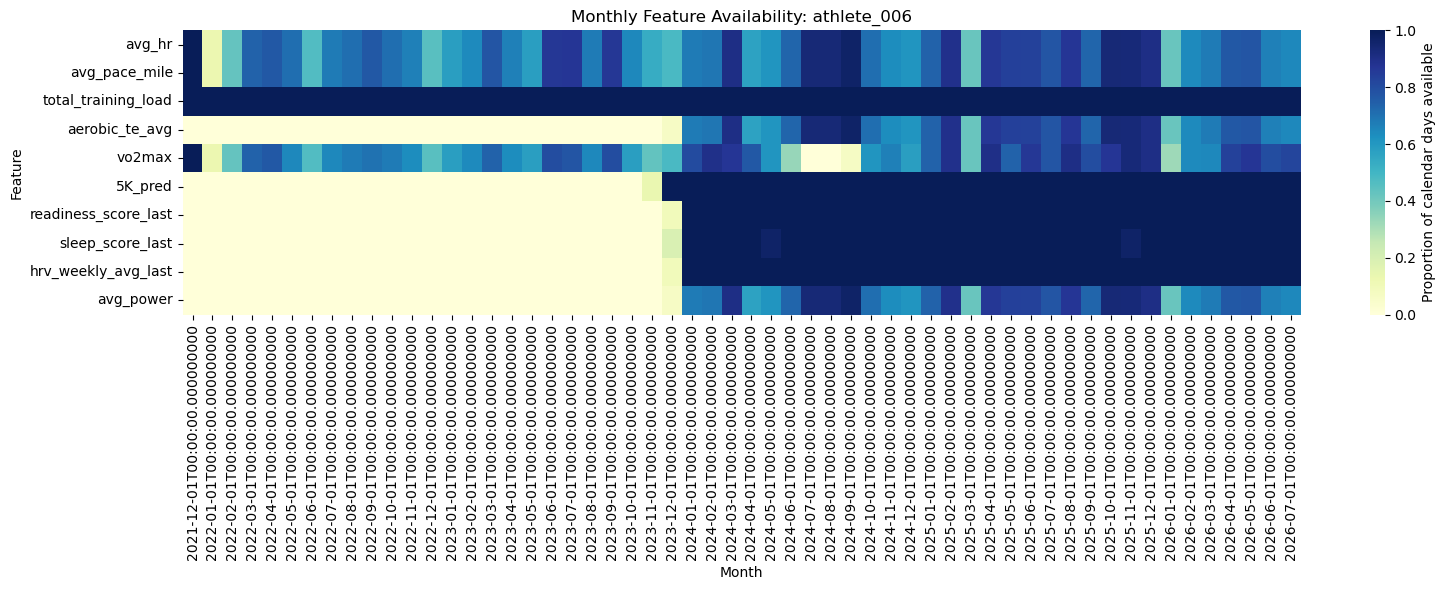

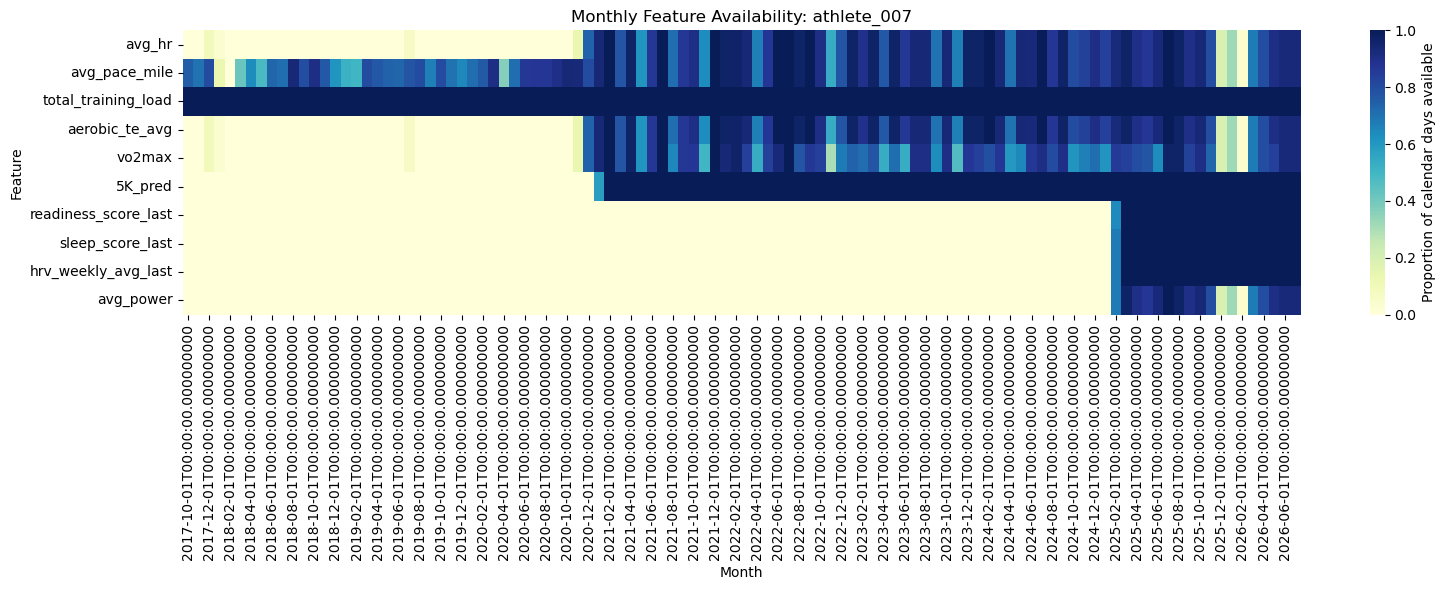

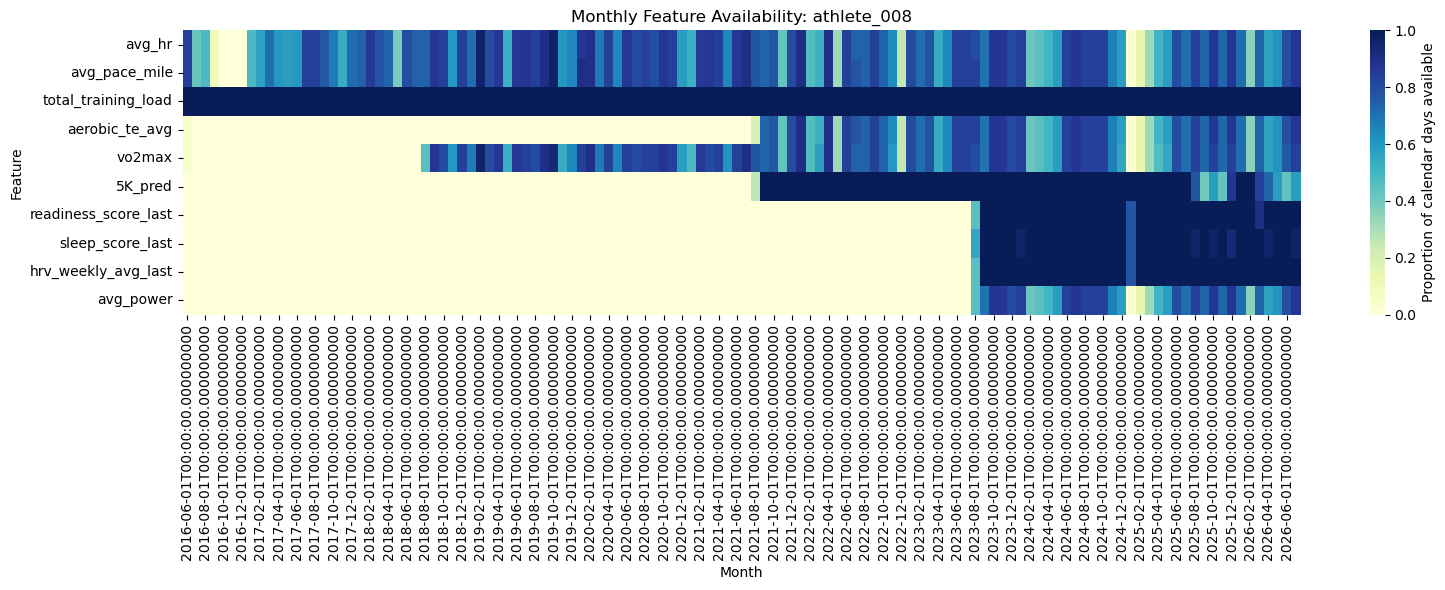

In [40]:
for athlete_id in sorted(df["athlete_id"].unique()):
    plot_athlete_timeline(
        data=df,
        athlete_id=athlete_id,
        features=timeline_features,
    )

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


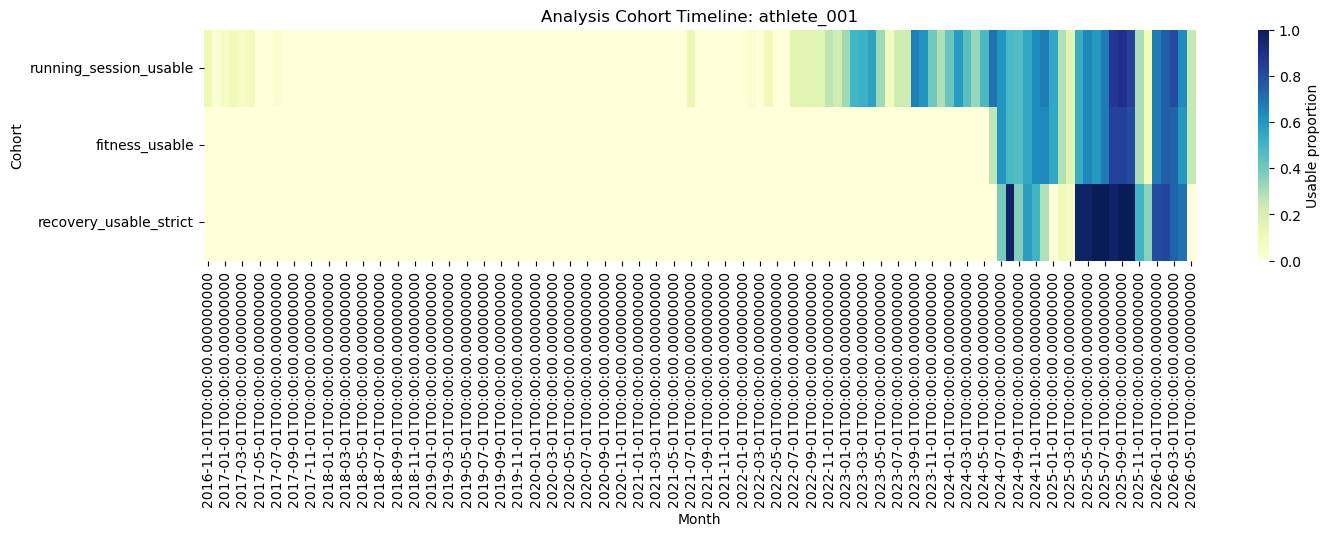

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


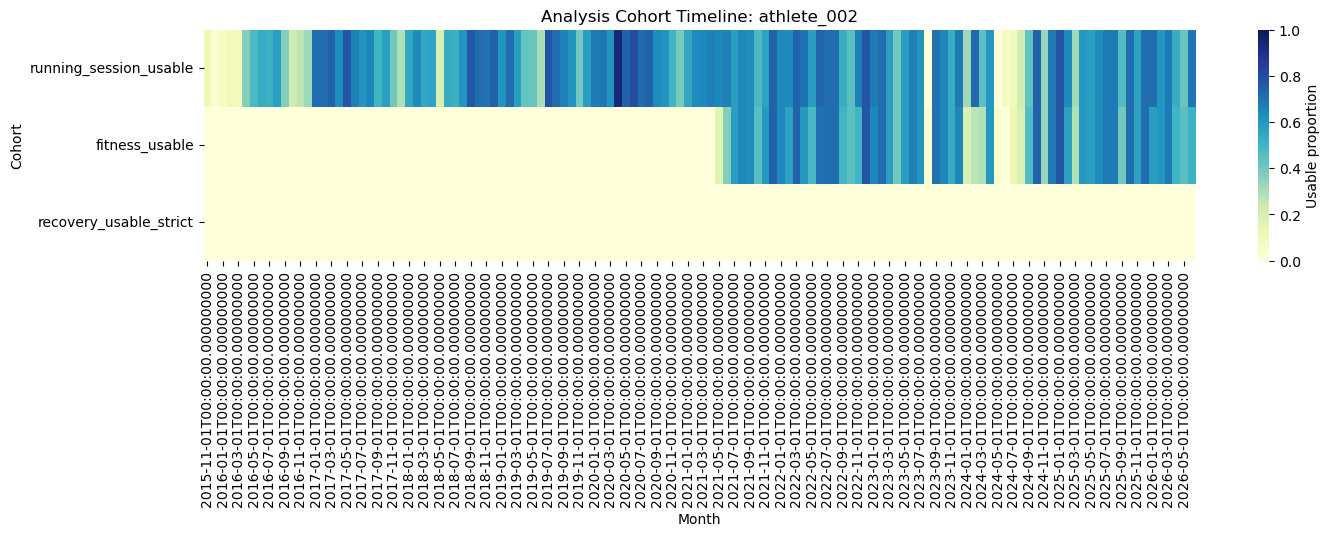

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


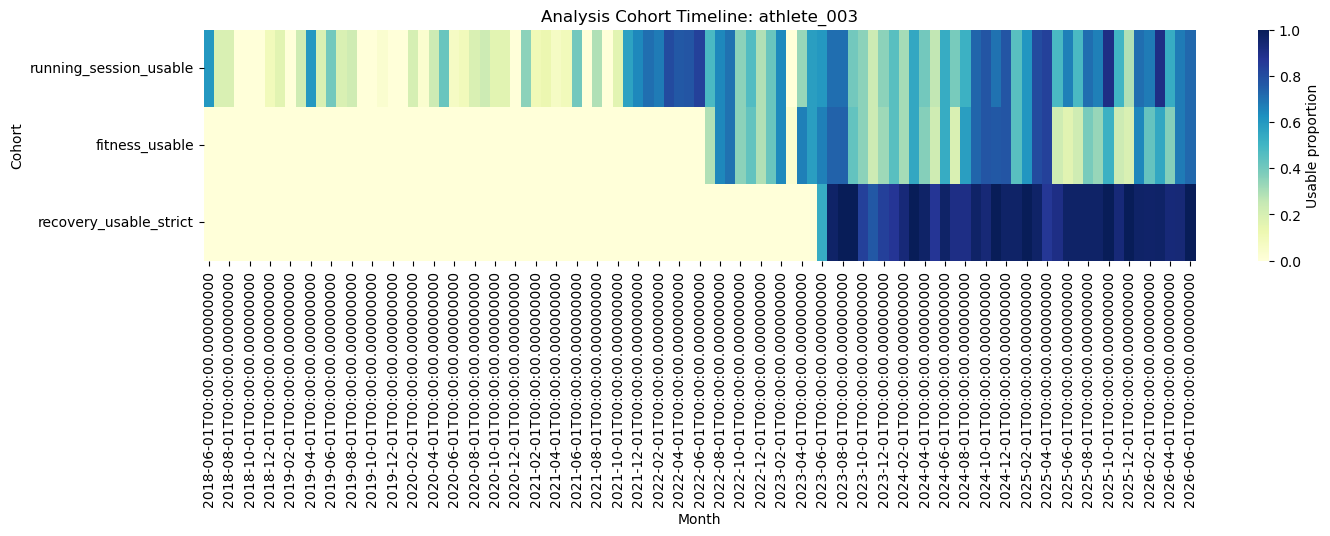

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


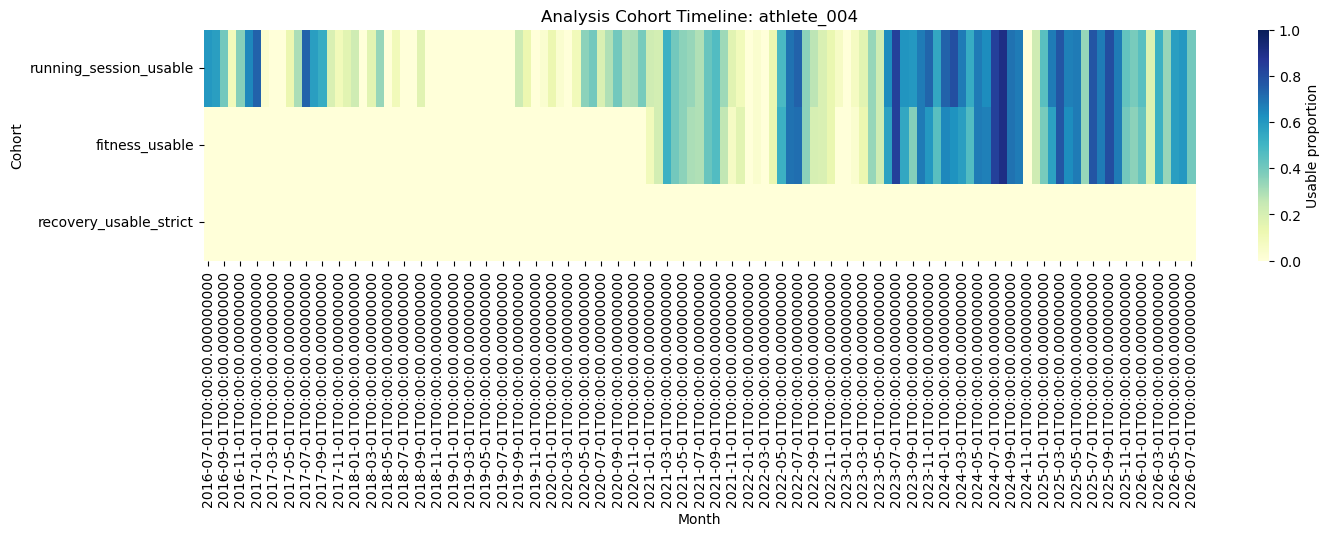

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


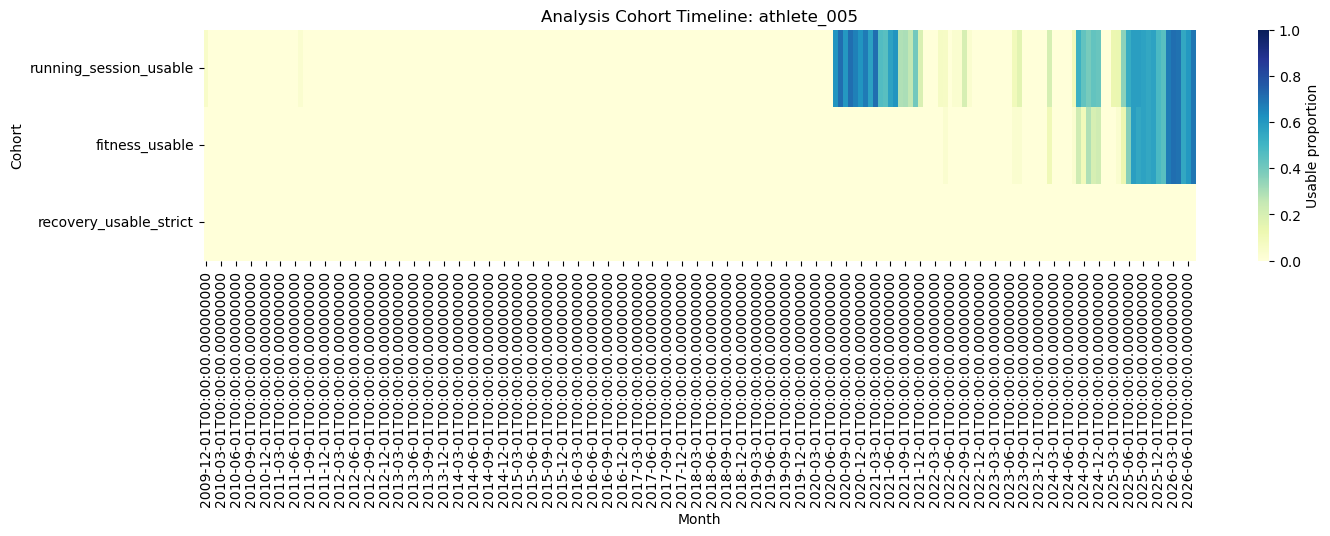

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


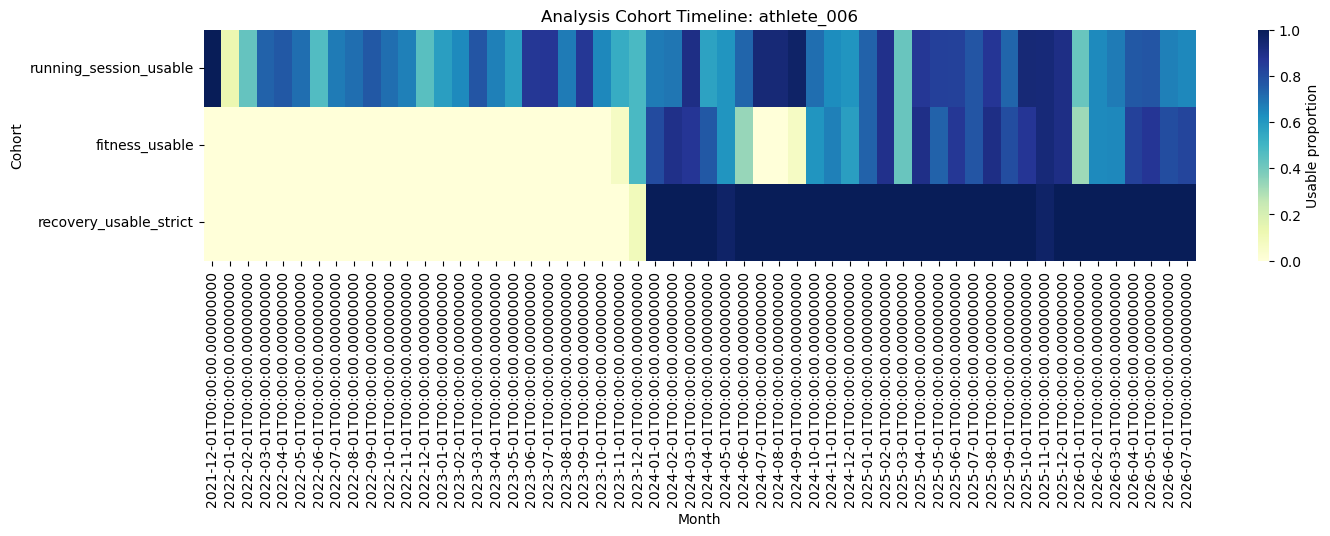

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


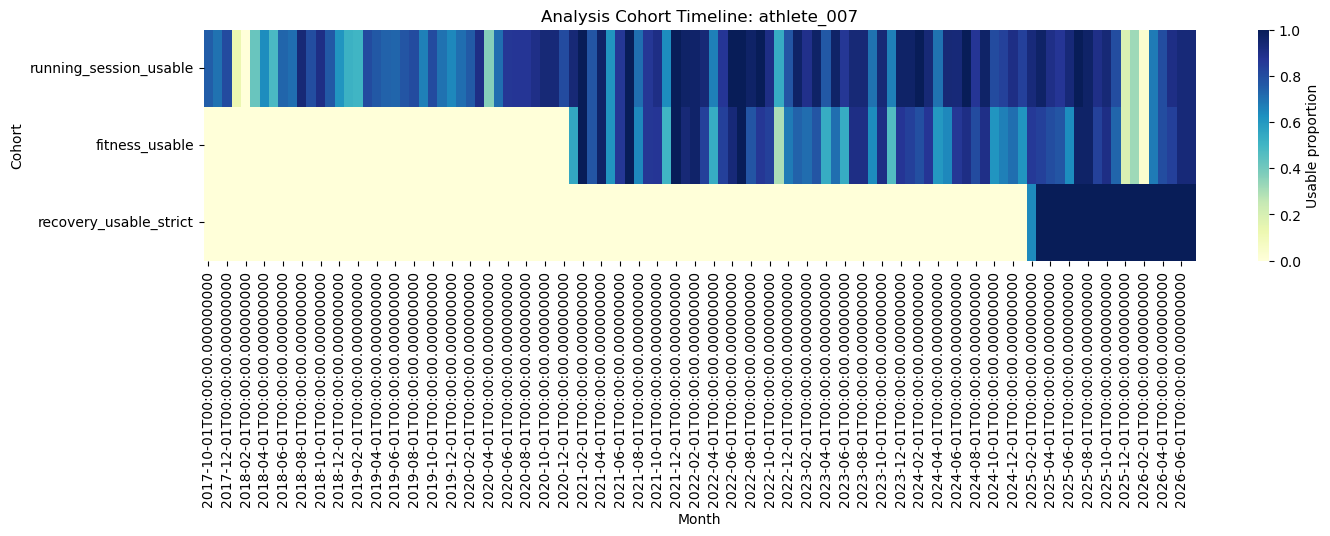

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_26660/3698229406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


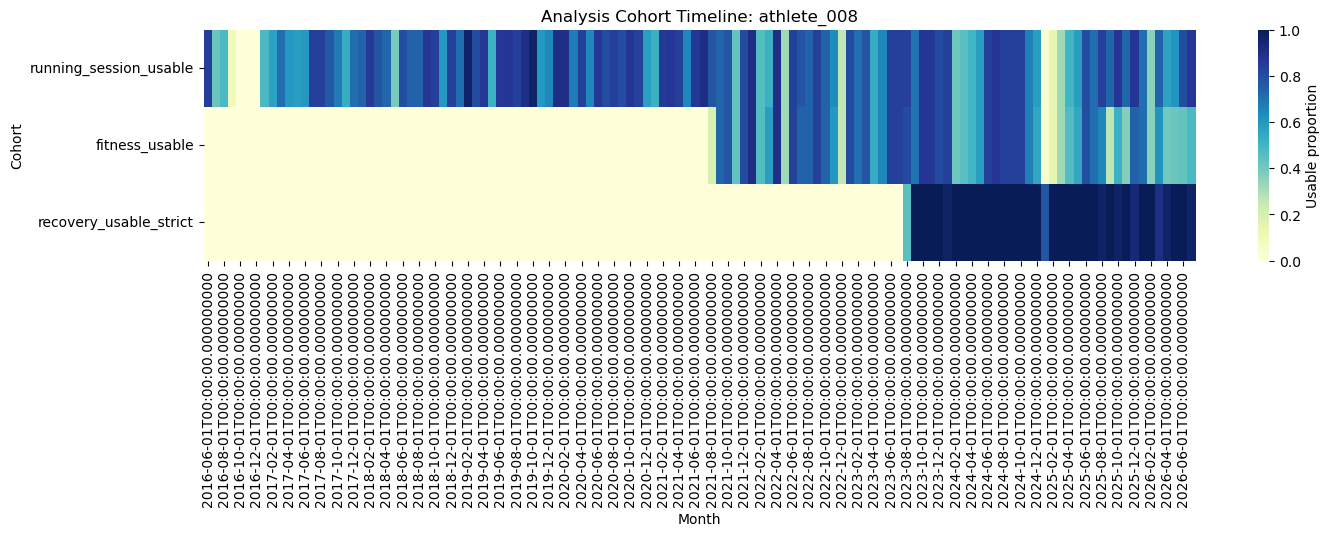

In [41]:
cohort_flags = [
    "running_session_usable",
    "fitness_usable",
    "recovery_usable_strict",
]

def plot_cohort_timeline(data, athlete_id):
    athlete_df = (
        data.loc[
            data["athlete_id"].eq(athlete_id),
            ["date"] + cohort_flags,
        ]
        .set_index("date")
        .sort_index()
    )

    monthly = (
        athlete_df[cohort_flags]
        .resample("MS")
        .mean()
        .T
    )

    plt.figure(figsize=(16, 3))

    sns.heatmap(
        monthly,
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Usable proportion"},
    )

    plt.title(f"Analysis Cohort Timeline: {athlete_id}")
    plt.xlabel("Month")
    plt.ylabel("Cohort")
    plt.tight_layout()
    plt.show()

for athlete_id in sorted(df["athlete_id"].unique()):
    plot_cohort_timeline(df, athlete_id)

In [42]:
running_session_df = df.loc[
    df["running_session_usable"]
].copy()

fitness_df = df.loc[
    df["fitness_usable"]
].copy()

recovery_df = df.loc[
    df["recovery_usable_strict"]
].copy()

print("Running sessions:", len(running_session_df))
print("Fitness athlete-days:", len(fitness_df))
print("Recovery athlete-days:", len(recovery_df))

print("\nAthletes per cohort:")
print(
    "Running:",
    running_session_df["athlete_id"].nunique()
)
print(
    "Fitness:",
    fitness_df["athlete_id"].nunique()
)
print(
    "Recovery:",
    recovery_df["athlete_id"].nunique()
)

Running sessions: 12140
Fitness athlete-days: 6535
Recovery athlete-days: 3990

Athletes per cohort:
Running: 8
Fitness: 8
Recovery: 5


In [43]:
def cohort_composition(data):
    counts = data["athlete_id"].value_counts()
    
    return pd.DataFrame({
        "rows": counts,
        "cohort_pct": 100 * counts / counts.sum(),
    }).round(1)

print("Running cohort")
display(cohort_composition(running_session_df))

print("Fitness cohort")
display(cohort_composition(fitness_df))

print("Recovery cohort")
display(cohort_composition(recovery_df))

Running cohort


,rows,cohort_pct
athlete_id,,
athlete_008,2548,21.0
athlete_007,2546,21.0
athlete_002,2158,17.8
athlete_004,1224,10.1
athlete_006,1170,9.6
athlete_003,1167,9.6
athlete_001,682,5.6
athlete_005,645,5.3


Fitness cohort


,rows,cohort_pct
athlete_id,,
athlete_007,1529,23.4
athlete_008,1136,17.4
athlete_002,997,15.3
athlete_004,860,13.2
athlete_003,704,10.8
athlete_006,640,9.8
athlete_001,391,6.0
athlete_005,278,4.3


Recovery cohort


,rows,cohort_pct
athlete_id,,
athlete_008,1062,26.6
athlete_003,1049,26.3
athlete_006,930,23.3
athlete_007,520,13.0
athlete_001,429,10.8


In [44]:
running_model_features = [
    "total_distance_km",
    "total_duration_minutes",
    "total_elevation_gain_m",
    "avg_hr",
    "avg_pace_mile",
    "total_training_load",
    "aerobic_te_avg",
    "anaerobic_te_avg",
]

In [45]:
running_feature_coverage = (
    running_session_df
    .groupby("athlete_id")[running_model_features]
    .agg(lambda x: x.notna().mean() * 100)
    .round(1)
)

display(running_feature_coverage.T)

athlete_id,athlete_001,athlete_002,athlete_003,athlete_004,athlete_005,athlete_006,athlete_007,athlete_008
total_distance_km,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
total_duration_minutes,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
total_elevation_gain_m,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
avg_hr,97.8,99.9,94.6,79.5,99.1,100.0,69.0,99.9
avg_pace_mile,100.0,99.9,100.0,100.0,99.8,100.0,100.0,100.0
total_training_load,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
aerobic_te_avg,97.8,69.5,94.9,80.4,55.5,60.0,69.0,48.1
anaerobic_te_avg,97.8,69.4,86.6,80.4,55.5,60.0,68.5,48.0


In [46]:
core_df = running_session_df.copy()

# Hilliness rather than raw elevation gain
core_df["elevation_per_km"] = (
    core_df["total_elevation_gain_m"]
    / core_df["total_distance_km"]
)

core_features = [
    "total_distance_km",
    "avg_pace_mile",
    "avg_hr",
    "elevation_per_km",
]

# Replace impossible values created by division or bad source data
core_df = core_df.replace([np.inf, -np.inf], np.nan)

# Retain sessions with all four core measurements
core_df = core_df.dropna(subset=core_features).copy()

print(f"Complete sessions: {len(core_df):,}")
print(f"Athletes represented: {core_df['athlete_id'].nunique()}")

Complete sessions: 11,007
Athletes represented: 8


In [47]:
sample_summary = (
    core_df.groupby("athlete_id")
    .agg(
        complete_sessions=("date", "size"),
        first_session=("date", "min"),
        last_session=("date", "max"),
    )
)

original_counts = (
    running_session_df["athlete_id"]
    .value_counts()
    .rename("original_sessions")
)

sample_summary = sample_summary.join(original_counts)

sample_summary["retained_pct"] = (
    100
    * sample_summary["complete_sessions"]
    / sample_summary["original_sessions"]
)

display(sample_summary.round(1))

,complete_sessions,first_session,last_session,original_sessions,retained_pct
athlete_id,,,,,
athlete_001,667,2021-07-08,2026-05-07,682,97.8
athlete_002,2153,2015-11-22,2026-06-26,2158,99.8
athlete_003,1104,2019-05-21,2026-06-29,1167,94.6
athlete_004,973,2020-04-20,2026-07-14,1224,79.5
athlete_005,638,2020-07-03,2026-07-16,645,98.9
athlete_006,1170,2021-12-31,2026-07-17,1170,100.0
athlete_007,1757,2017-12-26,2026-07-15,2546,69.0
athlete_008,2545,2016-06-12,2026-07-31,2548,99.9


In [48]:
display(
    core_df[core_features]
    .describe(
        percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
    )
    .T
)

,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
total_distance_km,11007.0,11.807027,6.427717,0.000890,0.377874,1.607578,3.657241,10.044440,24.153596,32.701242,43.132903,50.350580
avg_pace_mile,11007.0,9.397091,85.244780,4.367046,5.191693,5.887269,6.542528,8.062038,10.983784,14.077348,65.578524,8940.799922
avg_hr,11007.0,149.341875,13.320116,47.000000,78.000000,117.000000,127.000000,150.000000,171.000000,178.000000,186.994000,204.000000
elevation_per_km,11007.0,6.713143,48.178656,0.000000,0.000000,0.000000,0.310385,4.496935,12.922836,29.605240,80.333009,3568.739618


In [49]:
quality_checks = {
    "nonpositive_distance":
        core_df["total_distance_km"] <= 0,

    "nonpositive_pace":
        core_df["avg_pace_mile"] <= 0,

    "implausible_hr":
        ~core_df["avg_hr"].between(40, 230),

    "negative_elevation":
        core_df["elevation_per_km"] < 0,
}

for label, condition in quality_checks.items():
    print(f"{label}: {condition.sum():,}")

nonpositive_distance: 0
nonpositive_pace: 0
implausible_hr: 0
negative_elevation: 0


In [50]:
valid_session = (
    core_df["total_distance_km"].gt(0)
    & core_df["avg_pace_mile"].gt(0)
    & core_df["avg_hr"].between(40, 230)
    & core_df["elevation_per_km"].ge(0)
)

invalid_sessions = core_df.loc[
    ~valid_session,
    ["athlete_id", "date"] + core_features
]

print(f"Invalid sessions found: {len(invalid_sessions):,}")
display(invalid_sessions.head(20))

core_df = core_df.loc[valid_session].copy()

Invalid sessions found: 0


,athlete_id,date,total_distance_km,avg_pace_mile,avg_hr,elevation_per_km


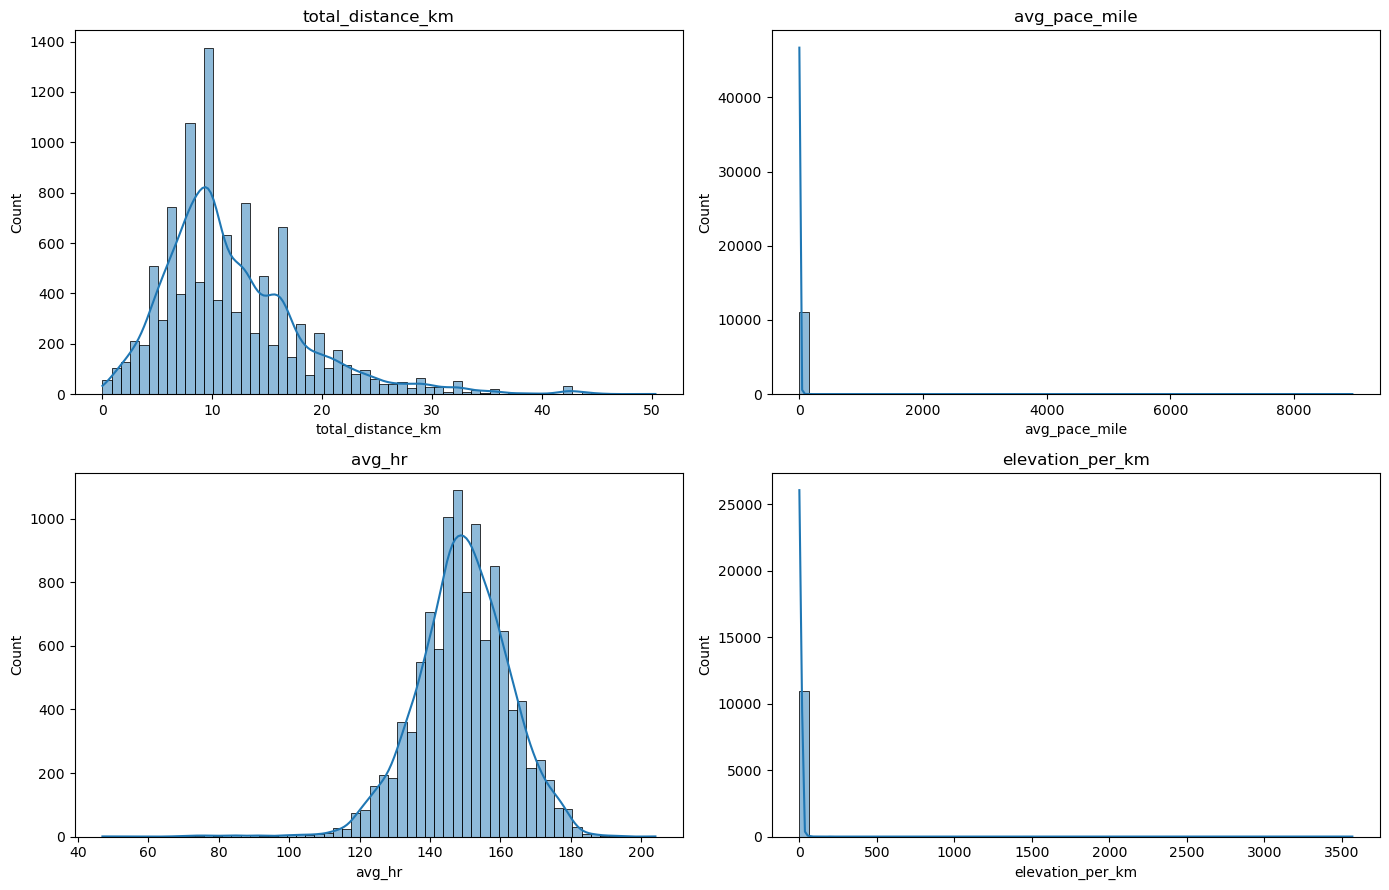

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for feature, ax in zip(core_features, axes.flat):
    sns.histplot(
        data=core_df,
        x=feature,
        bins=60,
        kde=True,
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [52]:
suspicious_sessions = core_df.loc[
    core_df["total_distance_km"].lt(1.0)
    | core_df["avg_pace_mile"].gt(30)
    | core_df["avg_pace_mile"].lt(3.0)
    | core_df["elevation_per_km"].gt(200),
    [
        "athlete_id",
        "date",
        "total_distance_km",
        "total_duration_minutes",
        "total_elevation_gain_m",
        "avg_pace_mile",
        "avg_hr",
        "elevation_per_km",
    ],
].sort_values("avg_pace_mile", ascending=False)

print(f"Suspicious sessions: {len(suspicious_sessions):,}")
display(suspicious_sessions.head(50))

Suspicious sessions: 96


,athlete_id,date,total_distance_km,total_duration_minutes,total_elevation_gain_m,avg_pace_mile,avg_hr,elevation_per_km
18577,athlete_005,2022-08-31,0.15647,1014.732682,0.000000,8940.799922,76.0,0.000000
4352,athlete_002,2018-04-24,0.48316,50.016268,0.000000,166.598759,143.0,0.000000
4375,athlete_002,2018-05-17,0.29989,30.008700,0.000000,160.613178,125.0,0.000000
4026,athlete_002,2017-06-02,0.34864,29.982867,1.214111,138.259790,91.0,3.482421
4376,athlete_002,2018-05-18,0.63129,50.005782,0.000000,127.725718,121.0,0.000000
4349,athlete_002,2018-04-21,0.80213,50.621452,0.438477,101.600001,134.0,0.546640
4903,athlete_002,2019-10-27,0.26520,14.732866,0.000000,89.407996,47.0,0.000000
4027,athlete_002,2017-06-03,0.37780,20.014034,0.754883,85.150477,82.0,1.998102
26641,athlete_008,2021-05-18,0.00089,0.045917,0.000000,83.041483,125.0,0.000000
4585,athlete_002,2018-12-13,1.60559,70.603117,0.000000,70.771502,144.0,0.000000


In [53]:
valid_core_session = (
    # Exclude accidental starts and negligible recordings
    core_df["total_distance_km"].ge(1.0)

    # Broad enough to retain racing, easy running, and run/walk sessions
    & core_df["avg_pace_mile"].between(3.0, 30.0)

    # Broad physiological range
    & core_df["avg_hr"].between(60, 210)

    # Retains extremely hilly/trail sessions
    & core_df["elevation_per_km"].between(0, 200)
)

excluded_core_df = core_df.loc[~valid_core_session].copy()
clean_core_df = core_df.loc[valid_core_session].copy()

print(f"Original sessions: {len(core_df):,}")
print(f"Excluded sessions: {len(excluded_core_df):,}")
print(f"Retained sessions: {len(clean_core_df):,}")
print(f"Retained percentage: {100 * len(clean_core_df) / len(core_df):.2f}%")

Original sessions: 11,007
Excluded sessions: 96
Retained sessions: 10,911
Retained percentage: 99.13%


,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
total_distance_km,10911.0,11.889505,6.376777,1.005420,1.303407,2.012571,4.025225,10.097420,24.154780,32.792479,43.195806,50.350580
avg_pace_mile,10911.0,8.373401,1.588298,4.367046,5.205816,5.887269,6.540454,8.052356,10.918792,12.892910,20.462322,27.824067
avg_hr,10911.0,149.537899,13.013097,71.000000,85.955000,118.000000,128.000000,150.000000,171.000000,178.000000,187.000000,204.000000
elevation_per_km,10911.0,5.715760,5.820292,0.000000,0.000000,0.000000,0.354820,4.507332,12.788719,28.257135,64.285896,196.159488


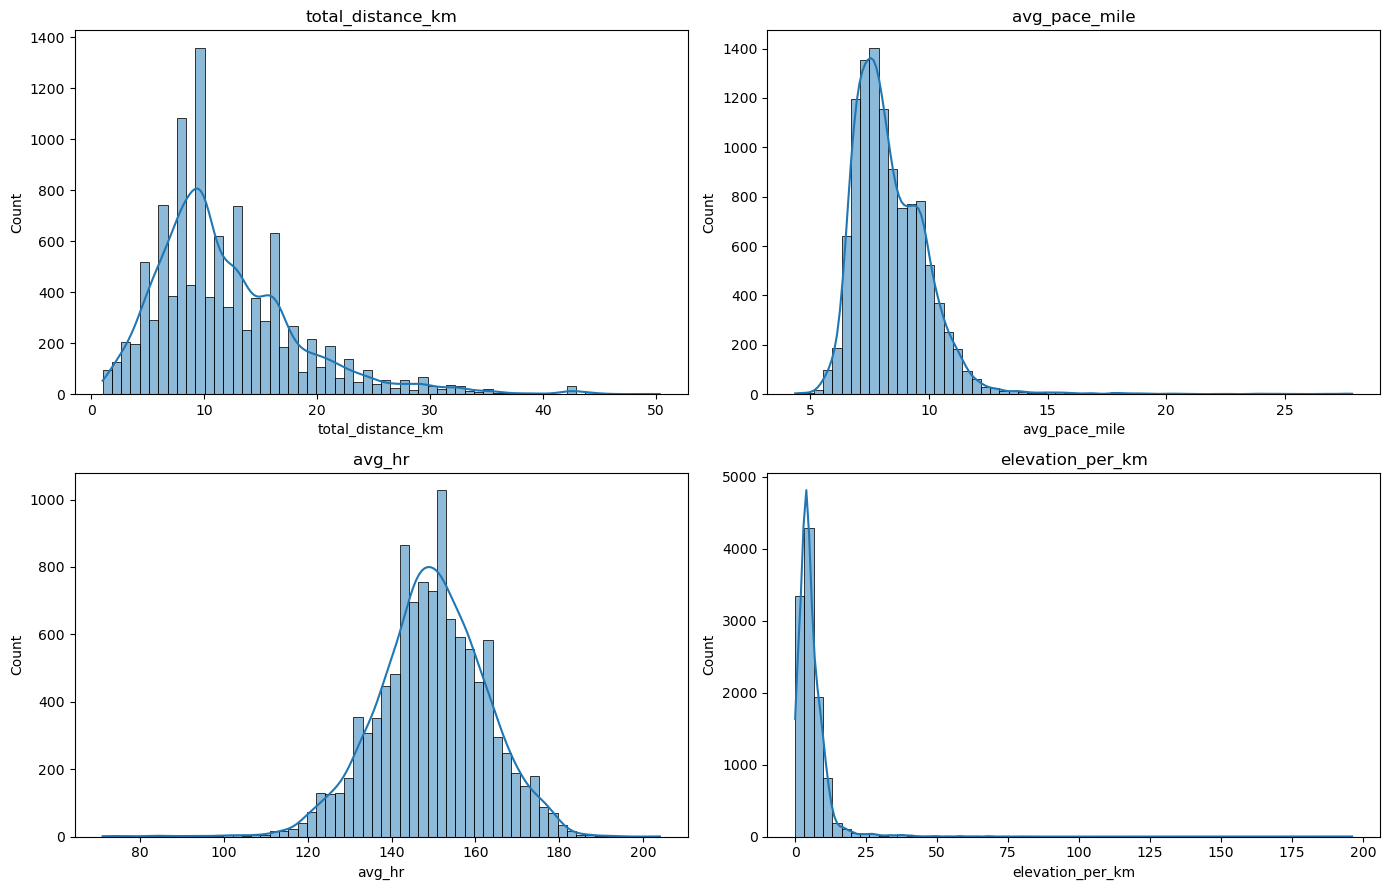

In [54]:
display(
    clean_core_df[core_features]
    .describe(
        percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
    )
    .T
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for feature, ax in zip(core_features, axes.flat):
    sns.histplot(
        data=clean_core_df,
        x=feature,
        bins=60,
        kde=True,
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [55]:
model_df = clean_core_df.copy()

model_df["log_distance"] = np.log1p(
    model_df["total_distance_km"]
)

model_df["log_elevation_per_km"] = np.log1p(
    model_df["elevation_per_km"]
)

model_features = [
    "log_distance",
    "avg_pace_mile",
    "avg_hr",
    "log_elevation_per_km",
]

In [56]:
standardized_features = []

for feature in model_features:
    z_feature = f"{feature}_within_z"

    model_df[z_feature] = (
        model_df.groupby("athlete_id")[feature]
        .transform(
            lambda x: (x - x.mean()) / x.std(ddof=0)
        )
    )

    standardized_features.append(z_feature)

X_core = model_df[standardized_features].copy()

print("Model matrix shape:", X_core.shape)
print("Missing values:", X_core.isna().sum().sum())

Model matrix shape: (10911, 4)
Missing values: 0


In [57]:
standardization_check = (
    model_df
    .groupby("athlete_id")[standardized_features]
    .agg(["mean", "std"])
)

display(standardization_check.round(2))

log_distance_within_z      avg_pace_mile_within_z       \
                             mean  std                   mean  std   
athlete_id                                                           
athlete_001                  -0.0  1.0                   -0.0  1.0   
athlete_002                  -0.0  1.0                    0.0  1.0   
athlete_003                  -0.0  1.0                    0.0  1.0   
athlete_004                  -0.0  1.0                   -0.0  1.0   
athlete_005                   0.0  1.0                   -0.0  1.0   
athlete_006                  -0.0  1.0                    0.0  1.0   
athlete_007                  -0.0  1.0                    0.0  1.0   
athlete_008                  -0.0  1.0                    0.0  1.0   

            avg_hr_within_z      log_elevation_per_km_within_z       
                       mean  std                          mean  std  
athlete_id                                                           
athlete_001            -0.0  1.0                           0.0  1.0  
athlete_002            -0.0  1.0                          -0.0  1.0  
athlete_003             0.0  1.0                           0.0  1.0  
athlete_004             0.0  1.0                          -0.0  1.0  
athlete_005             0.0  1.0                          -0.0  1.0  
athlete_006            -0.0  1.0                           0.0  1.0  
athlete_007             0.0  1.0                           0.0  1.0  
athlete_008             0.0  1.0                           0.0  1.0

In [58]:
display(
    X_core.describe(
        percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
    ).T
)

,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
log_distance_within_z,10911.0,-2.630916e-16,1.000046,-6.088347,-3.720898,-2.638610,-1.669891,0.027077,1.629419,2.422029,3.352963,3.869262
avg_pace_mile_within_z,10911.0,1.875505e-16,1.000046,-4.841029,-3.670076,-1.815323,-1.210105,-0.097786,1.431813,3.156854,9.704698,23.013456
avg_hr_within_z,10911.0,-3.457962e-16,1.000046,-8.373856,-5.384162,-2.565680,-1.616053,0.074400,1.522116,2.093622,2.923387,5.141455
log_elevation_per_km_within_z,10911.0,5.470222e-17,1.000046,-4.260062,-4.260062,-2.376782,-1.875954,0.038837,1.530283,2.544207,3.993653,6.917086


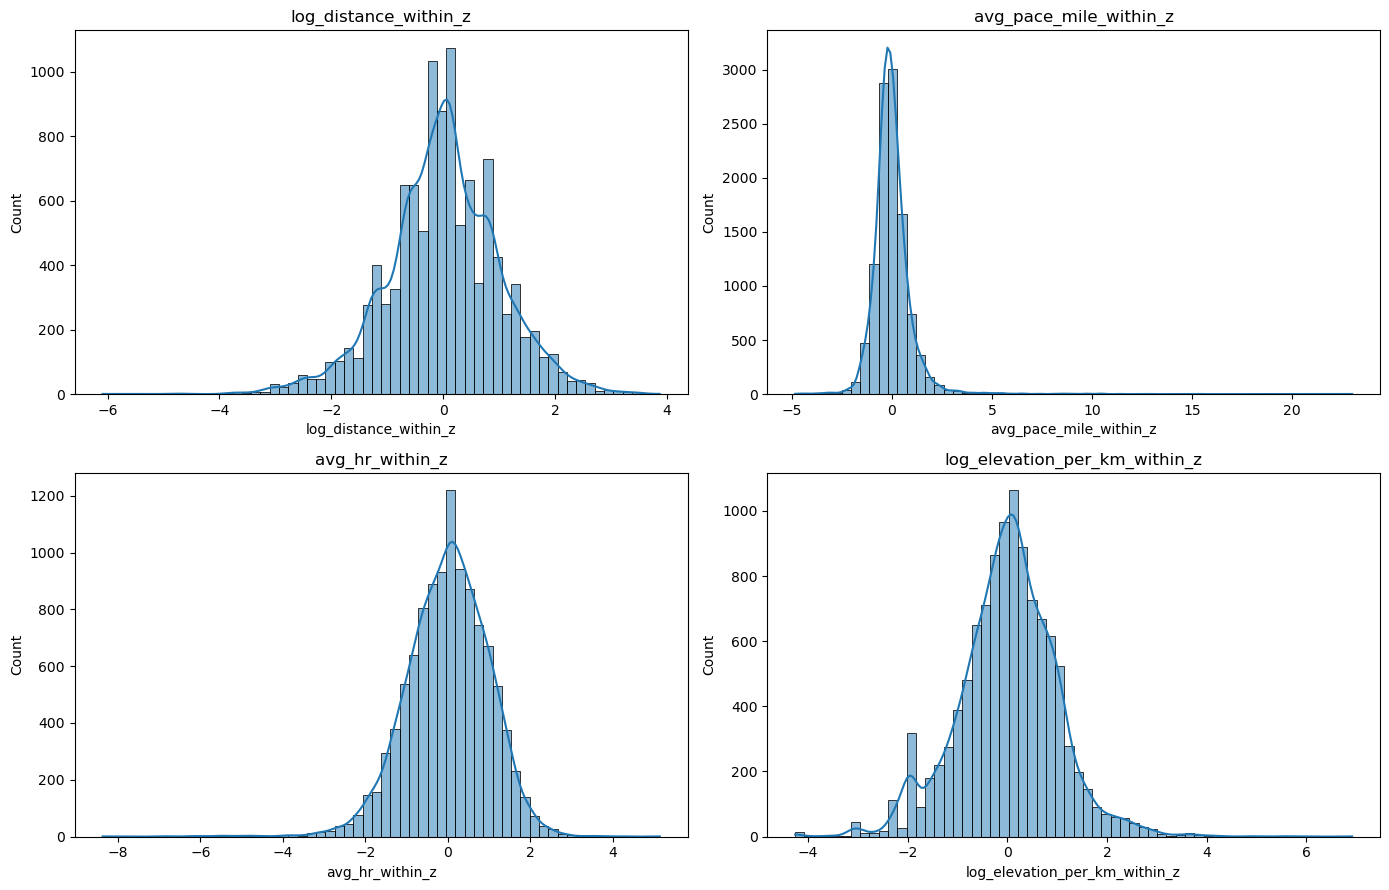

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for feature, ax in zip(standardized_features, axes.flat):
    sns.histplot(
        data=model_df,
        x=feature,
        bins=60,
        kde=True,
        ax=ax,
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [60]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_core)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(pca.n_components_)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(
        pca.explained_variance_ratio_
    ),
})

display(explained_variance.round(3))

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.381,0.381
1,PC2,0.276,0.657
2,PC3,0.204,0.861
3,PC4,0.139,1.000


In [61]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=standardized_features,
    columns=[
        f"PC{i+1}"
        for i in range(pca.n_components_)
    ],
)

display(pca_loadings.round(3))

,PC1,PC2,PC3,PC4
log_distance_within_z,-0.433,0.472,0.733,0.228
avg_pace_mile_within_z,0.652,0.247,0.003,0.717
avg_hr_within_z,-0.623,-0.074,-0.505,0.593
log_elevation_per_km_within_z,-0.003,0.843,-0.456,-0.286


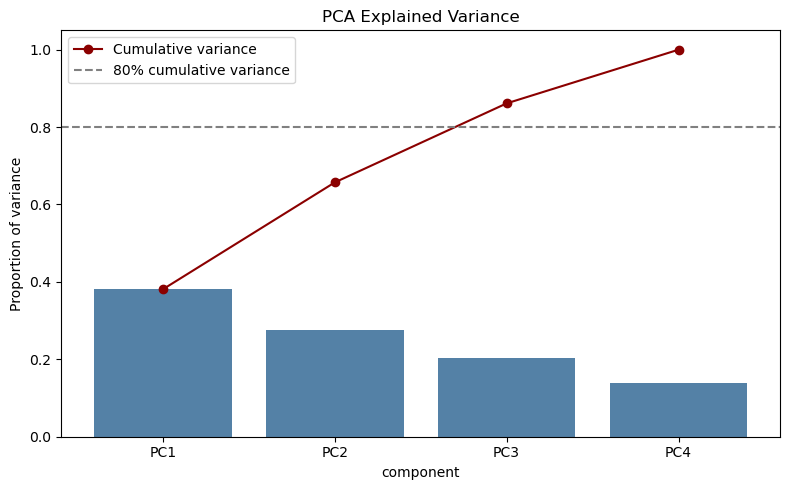

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=explained_variance,
    x="component",
    y="explained_variance_ratio",
    color="steelblue",
)

plt.plot(
    explained_variance["component"],
    explained_variance["cumulative_variance"],
    marker="o",
    color="darkred",
    label="Cumulative variance",
)

plt.axhline(
    0.80,
    linestyle="--",
    color="gray",
    label="80% cumulative variance",
)

plt.ylabel("Proportion of variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
for i in range(pca.n_components_):
    model_df[f"PC{i+1}"] = X_pca[:, i]

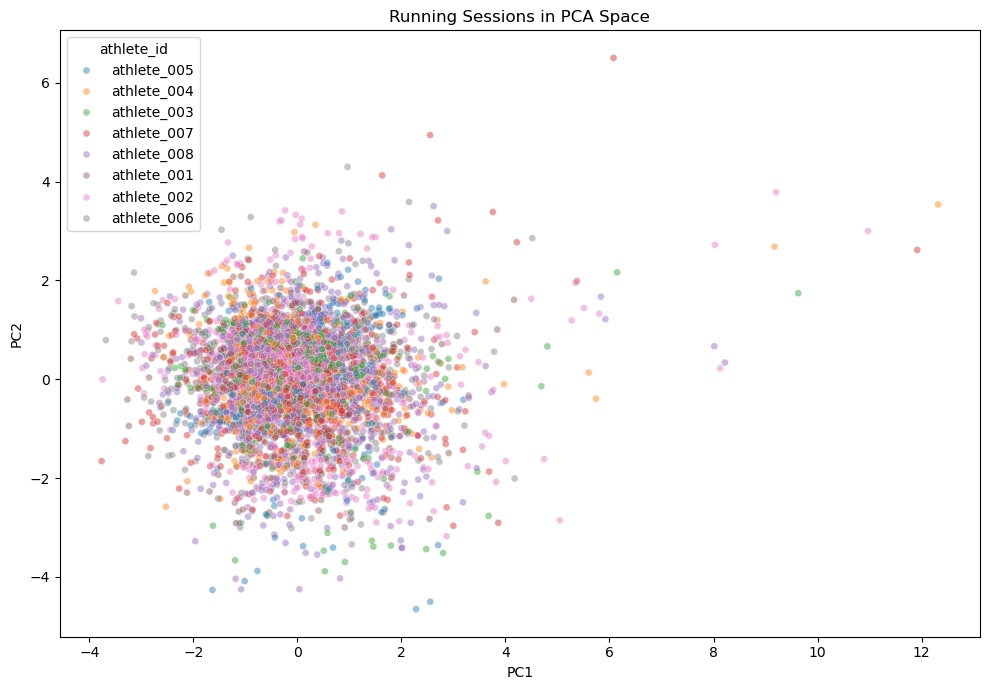

In [64]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=model_df.sample(
        min(5000, len(model_df)),
        random_state=42,
    ),
    x="PC1",
    y="PC2",
    hue="athlete_id",
    alpha=0.45,
    s=25,
)

plt.title("Running Sessions in PCA Space")
plt.tight_layout()
plt.show()

In [65]:
display(explained_variance.round(3))
display(pca_loadings.round(3))

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.381,0.381
1,PC2,0.276,0.657
2,PC3,0.204,0.861
3,PC4,0.139,1.000


,PC1,PC2,PC3,PC4
log_distance_within_z,-0.433,0.472,0.733,0.228
avg_pace_mile_within_z,0.652,0.247,0.003,0.717
avg_hr_within_z,-0.623,-0.074,-0.505,0.593
log_elevation_per_km_within_z,-0.003,0.843,-0.456,-0.286


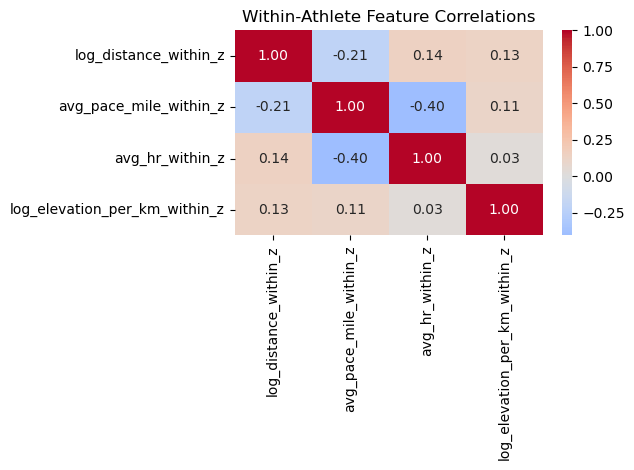

In [66]:
sns.heatmap(
    X_core.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Within-Athlete Feature Correlations")
plt.tight_layout()
plt.show()

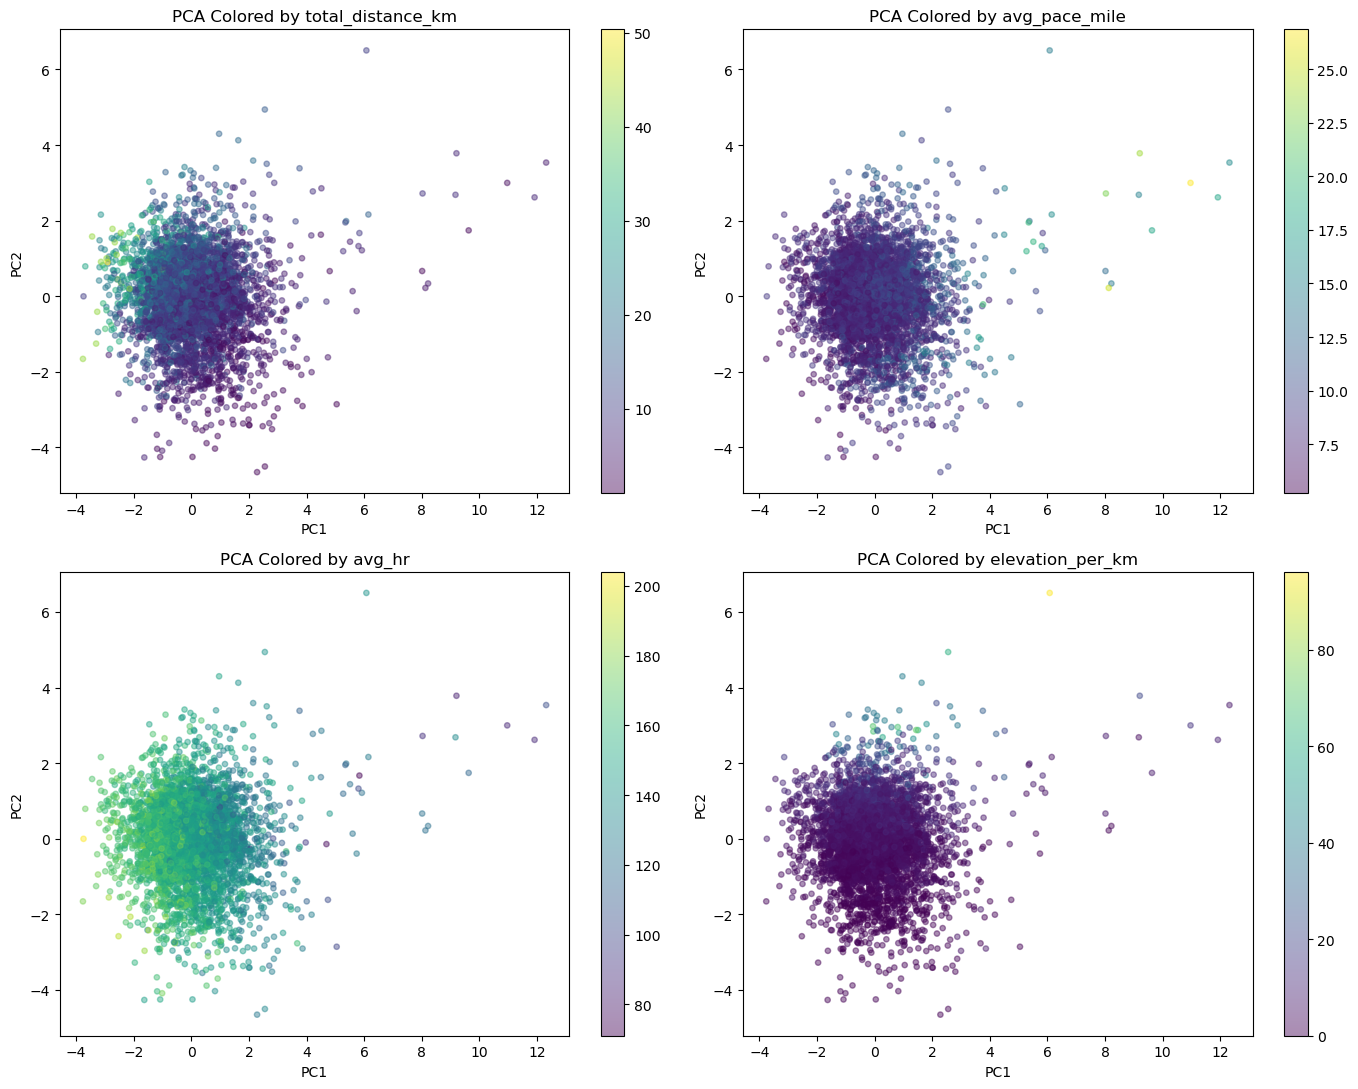

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

color_features = [
    "total_distance_km",
    "avg_pace_mile",
    "avg_hr",
    "elevation_per_km",
]

sample = model_df.sample(min(5000, len(model_df)), random_state=42)

for feature, ax in zip(color_features, axes.flat):
    points = ax.scatter(
        sample["PC1"],
        sample["PC2"],
        c=sample[feature],
        cmap="viridis",
        alpha=0.45,
        s=15,
    )
    ax.set_title(f"PCA Colored by {feature}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    fig.colorbar(points, ax=ax)

plt.tight_layout()
plt.show()

In [68]:
from sklearn.decomposition import KernelPCA
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = X_core.to_numpy()

# Median-distance heuristic for an initial gamma
sample_rng = np.random.default_rng(42)
sample_idx = sample_rng.choice(
    len(X),
    size=min(3000, len(X)),
    replace=False,
)

sample_distances = pairwise_distances(
    X[sample_idx],
    metric="euclidean",
)

nonzero_squared_distances = (
    sample_distances[sample_distances > 0] ** 2
)

median_squared_distance = np.median(
    nonzero_squared_distances
)

gamma_median = 1 / median_squared_distance

print("Median squared distance:", median_squared_distance)
print("Initial gamma:", gamma_median)

Median squared distance: 5.423894969591508
Initial gamma: 0.1843693518415076


In [69]:
gamma_values = [
    gamma_median / 4,
    gamma_median / 2,
    gamma_median,
    gamma_median * 2,
    gamma_median * 4,
]

kpca_results = {}

for gamma in gamma_values:
    kpca = KernelPCA(
        n_components=3,
        kernel="rbf",
        gamma=gamma,
        eigen_solver="randomized",
        random_state=42,
    )

    kpca_results[gamma] = kpca.fit_transform(X)

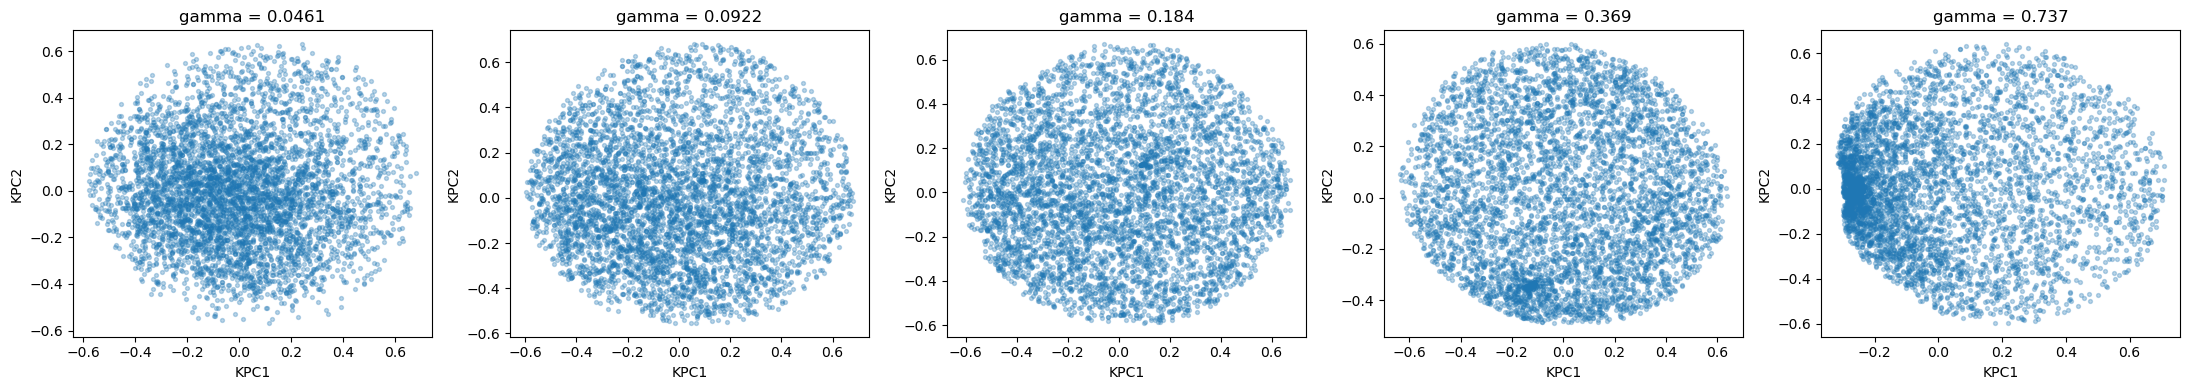

In [70]:
fig, axes = plt.subplots(
    1,
    len(gamma_values),
    figsize=(22, 4),
    sharex=False,
    sharey=False,
)

plot_idx = sample_rng.choice(
    len(model_df),
    size=min(5000, len(model_df)),
    replace=False,
)

for ax, gamma in zip(axes, gamma_values):
    embedding = kpca_results[gamma]

    ax.scatter(
        embedding[plot_idx, 0],
        embedding[plot_idx, 1],
        s=8,
        alpha=0.3,
    )

    ax.set_title(f"gamma = {gamma:.3g}")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.tight_layout()
plt.show()

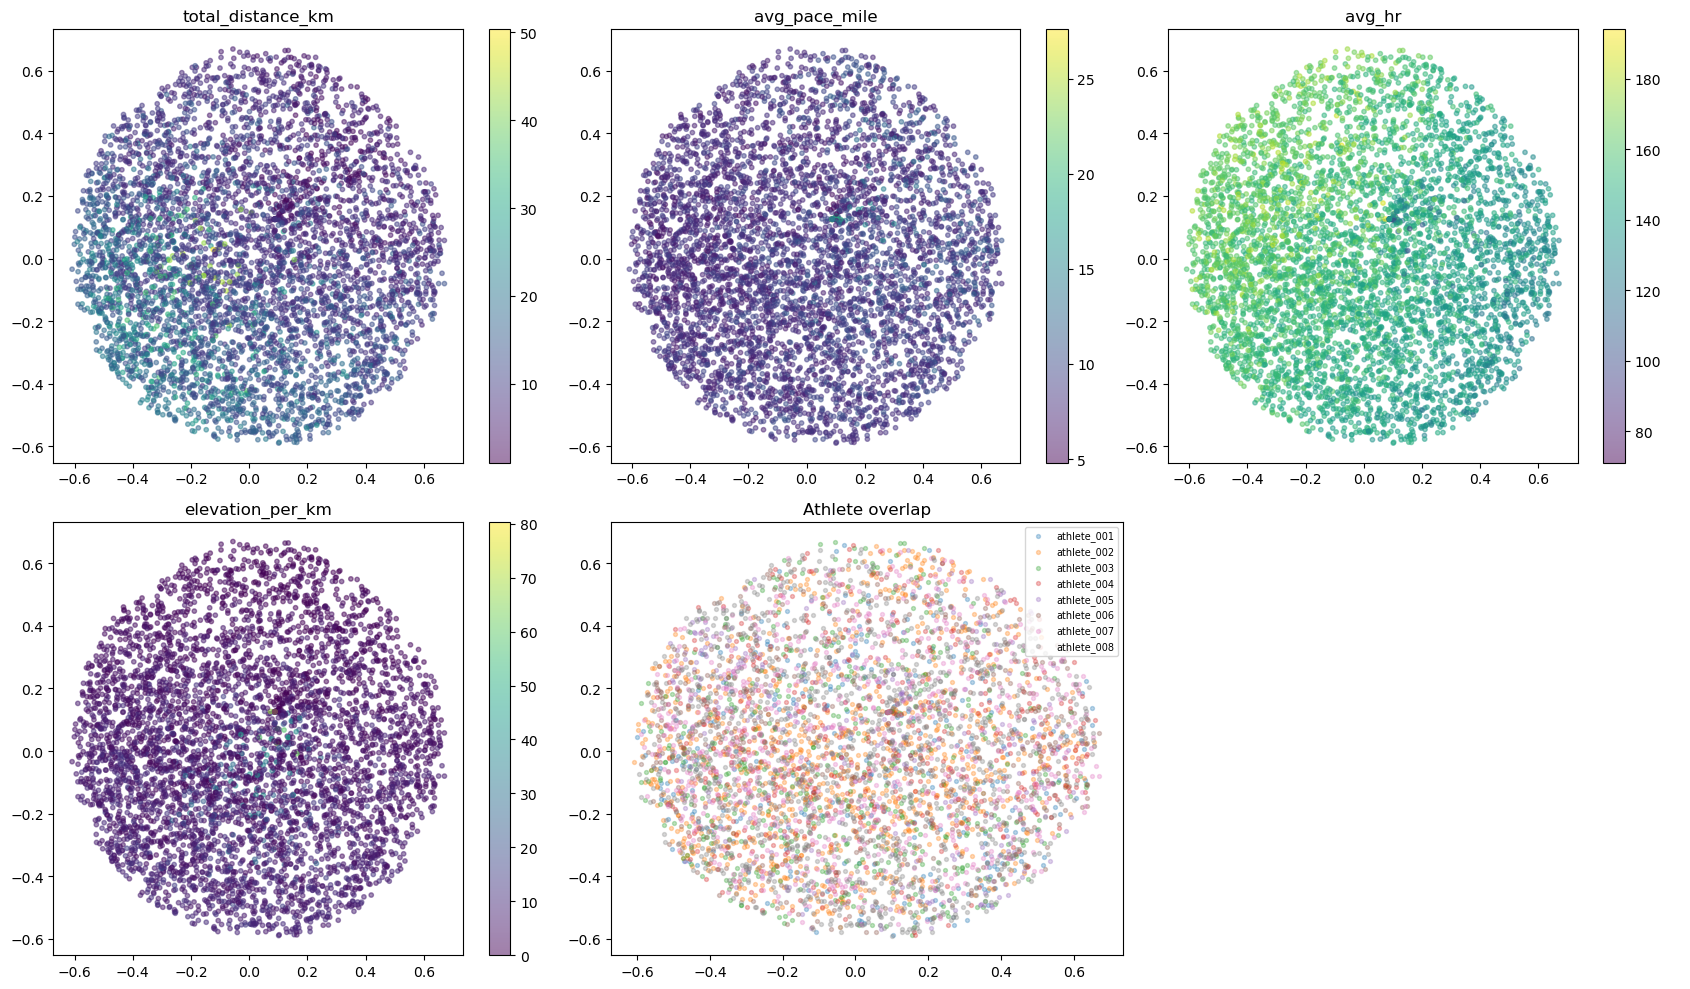

In [71]:
selected_gamma = gamma_median
embedding = kpca_results[selected_gamma]

kernel_df = model_df.copy()
kernel_df["KPC1"] = embedding[:, 0]
kernel_df["KPC2"] = embedding[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

color_features = [
    "total_distance_km",
    "avg_pace_mile",
    "avg_hr",
    "elevation_per_km",
]

sample = kernel_df.iloc[plot_idx]

for ax, feature in zip(axes.flat[:4], color_features):
    points = ax.scatter(
        sample["KPC1"],
        sample["KPC2"],
        c=sample[feature],
        cmap="viridis",
        s=10,
        alpha=0.5,
    )
    ax.set_title(feature)
    fig.colorbar(points, ax=ax)

for athlete_id, athlete_df in sample.groupby("athlete_id"):
    axes.flat[4].scatter(
        athlete_df["KPC1"],
        athlete_df["KPC2"],
        s=8,
        alpha=0.3,
        label=athlete_id,
    )

axes.flat[4].set_title("Athlete overlap")
axes.flat[4].legend(fontsize=7)

axes.flat[5].axis("off")

plt.tight_layout()
plt.show()

In [72]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd

X = X_core.to_numpy()
rng = np.random.default_rng(42)

results = []

for k in range(2, 9):
    full_labels = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=42,
    ).fit_predict(X)

    silhouette = silhouette_score(
        X,
        full_labels,
        sample_size=min(5000, len(X)),
        random_state=42,
    )

    stability_scores = []

    for seed in range(10):
        idx = rng.choice(
            len(X),
            size=int(0.8 * len(X)),
            replace=False,
        )

        labels_a = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=seed,
        ).fit_predict(X[idx])

        labels_b = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=seed + 100,
        ).fit_predict(X[idx])

        stability_scores.append(
            adjusted_rand_score(labels_a, labels_b)
        )

    results.append({
        "k": k,
        "silhouette": silhouette,
        "mean_stability": np.mean(stability_scores),
    })

cluster_diagnostics = pd.DataFrame(results)
display(cluster_diagnostics)

,k,silhouette,mean_stability
0,2,0.220098,0.983694
1,3,0.198001,0.978541
2,4,0.183336,0.977961
3,5,0.191583,0.986005
4,6,0.189823,0.966258
5,7,0.181034,0.936437
6,8,0.169193,0.944117
